# 10年定着予測 - データ探索的分析（EDA）

## 概要
- **課題**: 入社後2年間（0-23ヶ月）のデータから、入社10年後（120ヶ月時点）の在籍を予測
- **評価指標**: Log Loss（対数損失）
- **データ**: 属性データ（社員1名=1行）+ 月次データ（社員×月=複数行）

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# プロジェクトルートの設定（ローカル実行用）
PROJECT_ROOT = Path.cwd().parent.parent
INPUT_DIR = PROJECT_ROOT / "data" / "input"

# データ読み込み
train_persona = pd.read_csv(INPUT_DIR / "employee_persona_train.csv")
test_persona = pd.read_csv(INPUT_DIR / "employee_persona_test.csv")
train_monthly = pd.read_csv(INPUT_DIR / "employee_monthly_train.csv")
test_monthly = pd.read_csv(INPUT_DIR / "employee_monthly_test.csv")
train_monthly_full = pd.read_csv(INPUT_DIR / "employee_monthly_train_full.csv")

print("✓ データ読み込み完了")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")

✓ データ読み込み完了
PROJECT_ROOT: /Users/hayashikaito/Library/CloudStorage/GoogleDrive-1122hkaito@gmail.com/マイドライブ/jaggle_2026


## 1. 基本情報の確認

まず、各データセットの基本的な情報を確認します。

In [2]:
# データセットの基本情報
print("="*60)
print("データセットサイズ")
print("="*60)
print(f"Train 属性データ: {train_persona.shape[0]:,}行 × {train_persona.shape[1]}列")
print(f"Test 属性データ:  {test_persona.shape[0]:,}行 × {test_persona.shape[1]}列")
print(f"Train 月次データ: {train_monthly.shape[0]:,}行 × {train_monthly.shape[1]}列")
print(f"Test 月次データ:  {test_monthly.shape[0]:,}行 × {test_monthly.shape[1]}列")
print(f"Train 月次データ(Full): {train_monthly_full.shape[0]:,}行 × {train_monthly_full.shape[1]}列")
print()

# 属性データのカラム一覧
print("="*60)
print("属性データのカラム一覧")
print("="*60)
for i, col in enumerate(train_persona.columns, 1):
    print(f"{i:2d}. {col}")

データセットサイズ
Train 属性データ: 2,761行 × 20列
Test 属性データ:  2,502行 × 19列
Train 月次データ: 65,754行 × 29列
Test 月次データ:  60,048行 × 29列
Train 月次データ(Full): 257,509行 × 29列

属性データのカラム一覧
 1. 社員ID
 2. 入社日
 3. 入社区分
 4. 入社時年齢
 5. 最終学歴
 6. 専攻分野
 7. 前職経験月数
 8. 前職職種
 9. 採用経路
10. 性別
11. 初期職種
12. 初期部署ID
13. 初期勤務地
14. 初期等級
15. 初期役割
16. 初任給_円
17. 入社時メモ
18. 上司からのフィードバック
19. 同僚からのフィードバック
20. 10年定着ラベル


In [3]:
# 月次データのカラム一覧
print("="*60)
print("月次データのカラム一覧")
print("="*60)
for i, col in enumerate(train_monthly.columns, 1):
    print(f"{i:2d}. {col}")

月次データのカラム一覧
 1. 社員ID
 2. 年月
 3. 経過月数
 4. 年齢
 5. 月末在籍状態
 6. 部署ID
 7. 職種
 8. 役割
 9. 等級
10. 上司ID
11. 勤務地
12. 月例給与_円
13. 360度評価_親和度
14. 360度評価_信頼度
15. 360度評価_主体度
16. 360度評価_学習度
17. 360度評価_共有貢献度
18. 360度評価更新フラグ
19. 360度評価者数
20. 担当プロジェクト数
21. 顧客満足度評価
22. 残業時間
23. 有給取得日数
24. 欠勤日数
25. 研修時間
26. 自己学習（詳細）
27. 上司との面談実施回数
28. 情報共有件数
29. 在宅勤務日数


In [4]:
# 属性データの欠損値
print("="*60)
print("属性データ（Train）の欠損値")
print("="*60)
missing_persona = train_persona.isnull().sum()
missing_persona = missing_persona[missing_persona > 0].sort_values(ascending=False)
if len(missing_persona) > 0:
    for col, count in missing_persona.items():
        pct = 100 * count / len(train_persona)
        print(f"{col:30s}: {count:5d}件 ({pct:5.2f}%)")
else:
    print("欠損なし")

print()

# 月次データの欠損値
print("="*60)
print("月次データ（Train）の欠損値")
print("="*60)
missing_monthly = train_monthly.isnull().sum()
missing_monthly = missing_monthly[missing_monthly > 0].sort_values(ascending=False)
if len(missing_monthly) > 0:
    for col, count in missing_monthly.items():
        pct = 100 * count / len(train_monthly)
        print(f"{col:30s}: {count:6d}件 ({pct:5.2f}%)")
else:
    print("欠損なし")

属性データ（Train）の欠損値
前職職種                          :  2025件 (73.34%)

月次データ（Train）の欠損値
顧客満足度評価                       :  42969件 (65.35%)
担当プロジェクト数                     :  31228件 (47.49%)
360度評価_親和度                    :  13593件 (20.67%)
360度評価_信頼度                    :  13593件 (20.67%)
360度評価_主体度                    :  13593件 (20.67%)
360度評価_学習度                    :  13593件 (20.67%)
360度評価_共有貢献度                  :  13593件 (20.67%)
360度評価者数                      :  13593件 (20.67%)


## 2. 目的変数（10年定着ラベル）の分析

定着率とクラスバランスを確認します。

10年定着ラベルの分布
定着（1）: 1,559名 (56.47%)
退職（0）: 1,202名 (43.53%)

定着率: 0.5647 (56.47%)


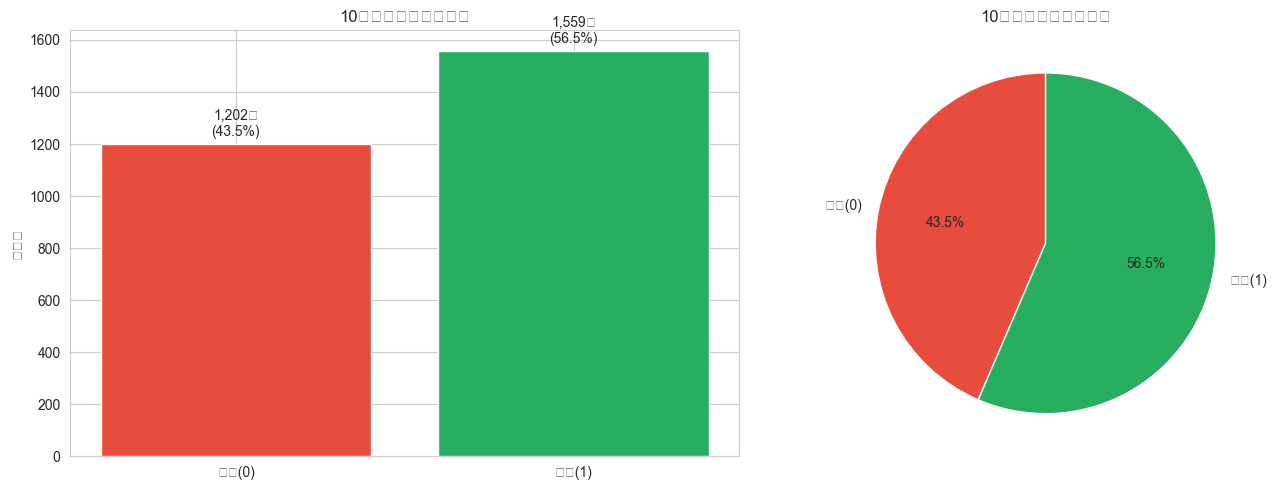

In [5]:
# 目的変数の分布
target_col = "10年定着ラベル"
target_counts = train_persona[target_col].value_counts().sort_index()
target_ratio = train_persona[target_col].mean()

print("="*60)
print("10年定着ラベルの分布")
print("="*60)
print(f"定着（1）: {target_counts[1]:,}名 ({100*target_counts[1]/len(train_persona):.2f}%)")
print(f"退職（0）: {target_counts[0]:,}名 ({100*target_counts[0]/len(train_persona):.2f}%)")
print(f"\n定着率: {target_ratio:.4f} ({100*target_ratio:.2f}%)")

# 可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 棒グラフ
axes[0].bar(['退職(0)', '定着(1)'], target_counts.values, color=['#e74c3c', '#27ae60'])
axes[0].set_ylabel('社員数')
axes[0].set_title('10年定着ラベルの分布')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 30, f'{v:,}名\n({100*v/len(train_persona):.1f}%)', ha='center')

# 円グラフ
axes[1].pie(target_counts.values, labels=['退職(0)', '定着(1)'], autopct='%1.1f%%', 
            colors=['#e74c3c', '#27ae60'], startangle=90)
axes[1].set_title('10年定着ラベルの割合')

plt.tight_layout()
plt.show()

## 3. 属性データの探索的分析

社員の属性情報と目的変数との関係を分析します。

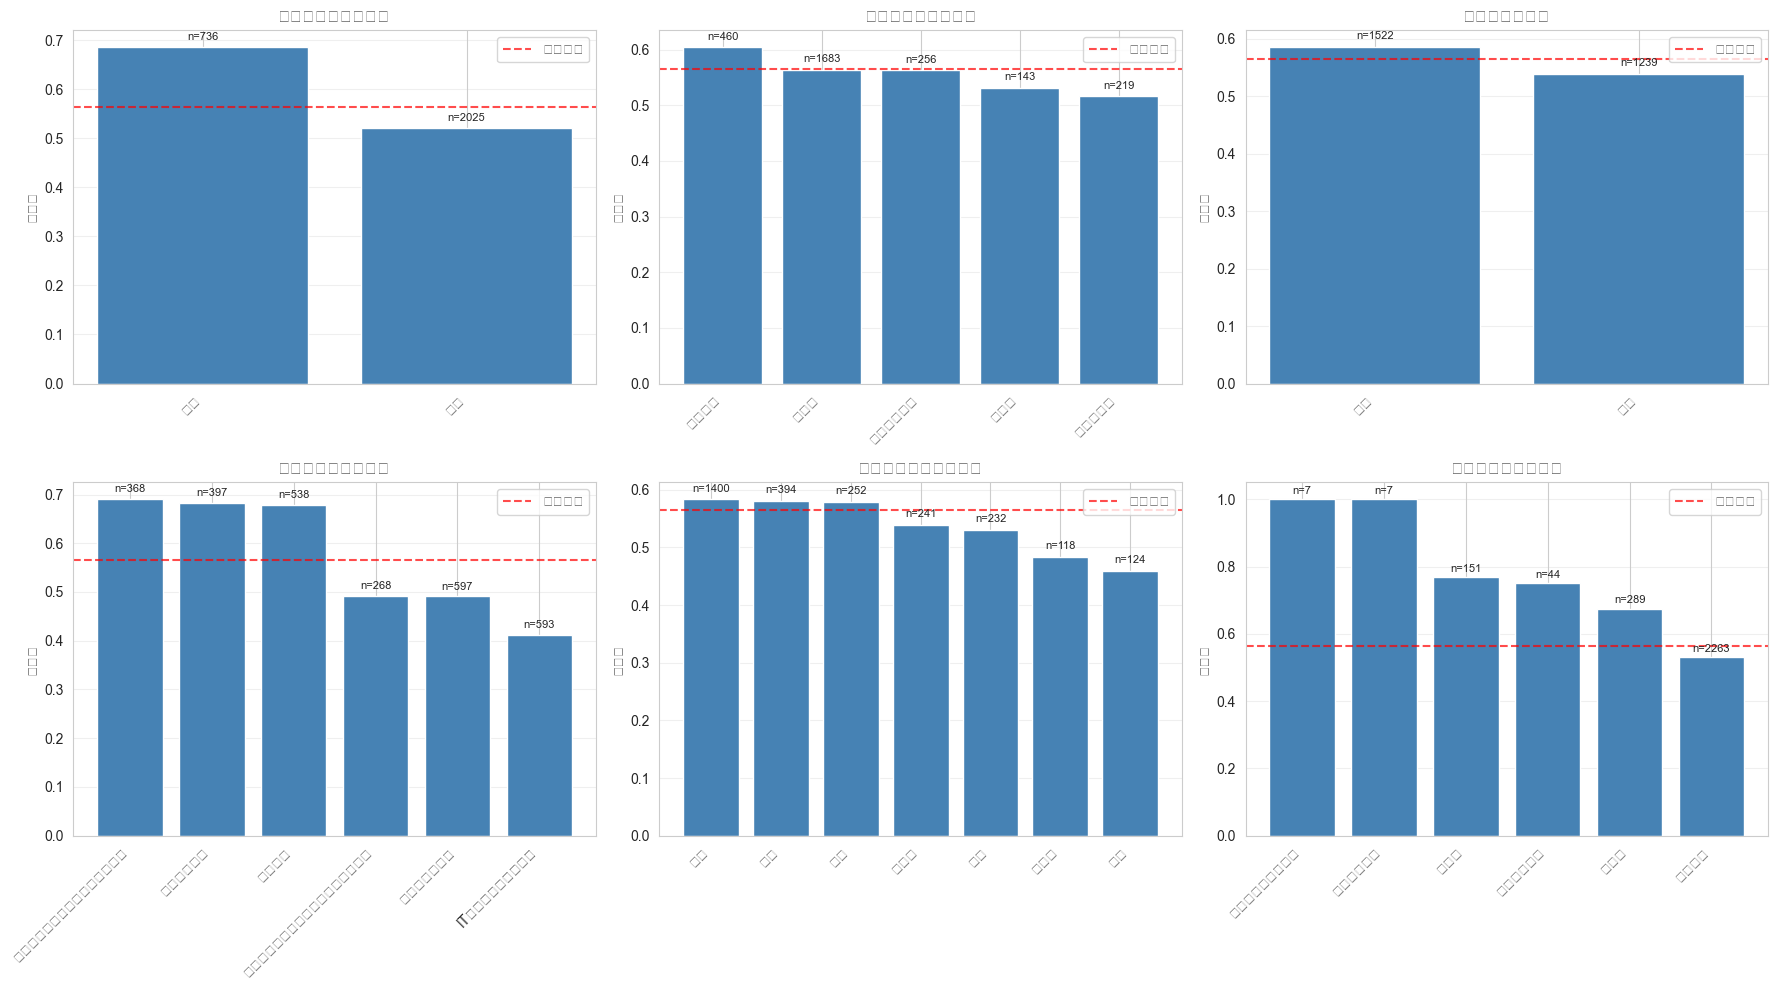

In [6]:
# 主要なカテゴリカル変数と定着率の関係
categorical_cols = ['入社区分', '最終学歴', '性別', '初期職種', '初期勤務地', '初期役割']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    # 各カテゴリごとの定着率を計算
    retention_by_cat = train_persona.groupby(col)[target_col].agg(['mean', 'count'])
    retention_by_cat = retention_by_cat.sort_values('mean', ascending=False)
    
    # プロット
    ax = axes[idx]
    bars = ax.bar(range(len(retention_by_cat)), retention_by_cat['mean'], color='steelblue')
    ax.set_xticks(range(len(retention_by_cat)))
    ax.set_xticklabels(retention_by_cat.index, rotation=45, ha='right')
    ax.set_ylabel('定着率')
    ax.set_title(f'{col}別の定着率')
    ax.axhline(y=target_ratio, color='red', linestyle='--', alpha=0.7, label='全体平均')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # 各バーの上にサンプル数を表示
    for i, (bar, count) in enumerate(zip(bars, retention_by_cat['count'])):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'n={int(count)}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

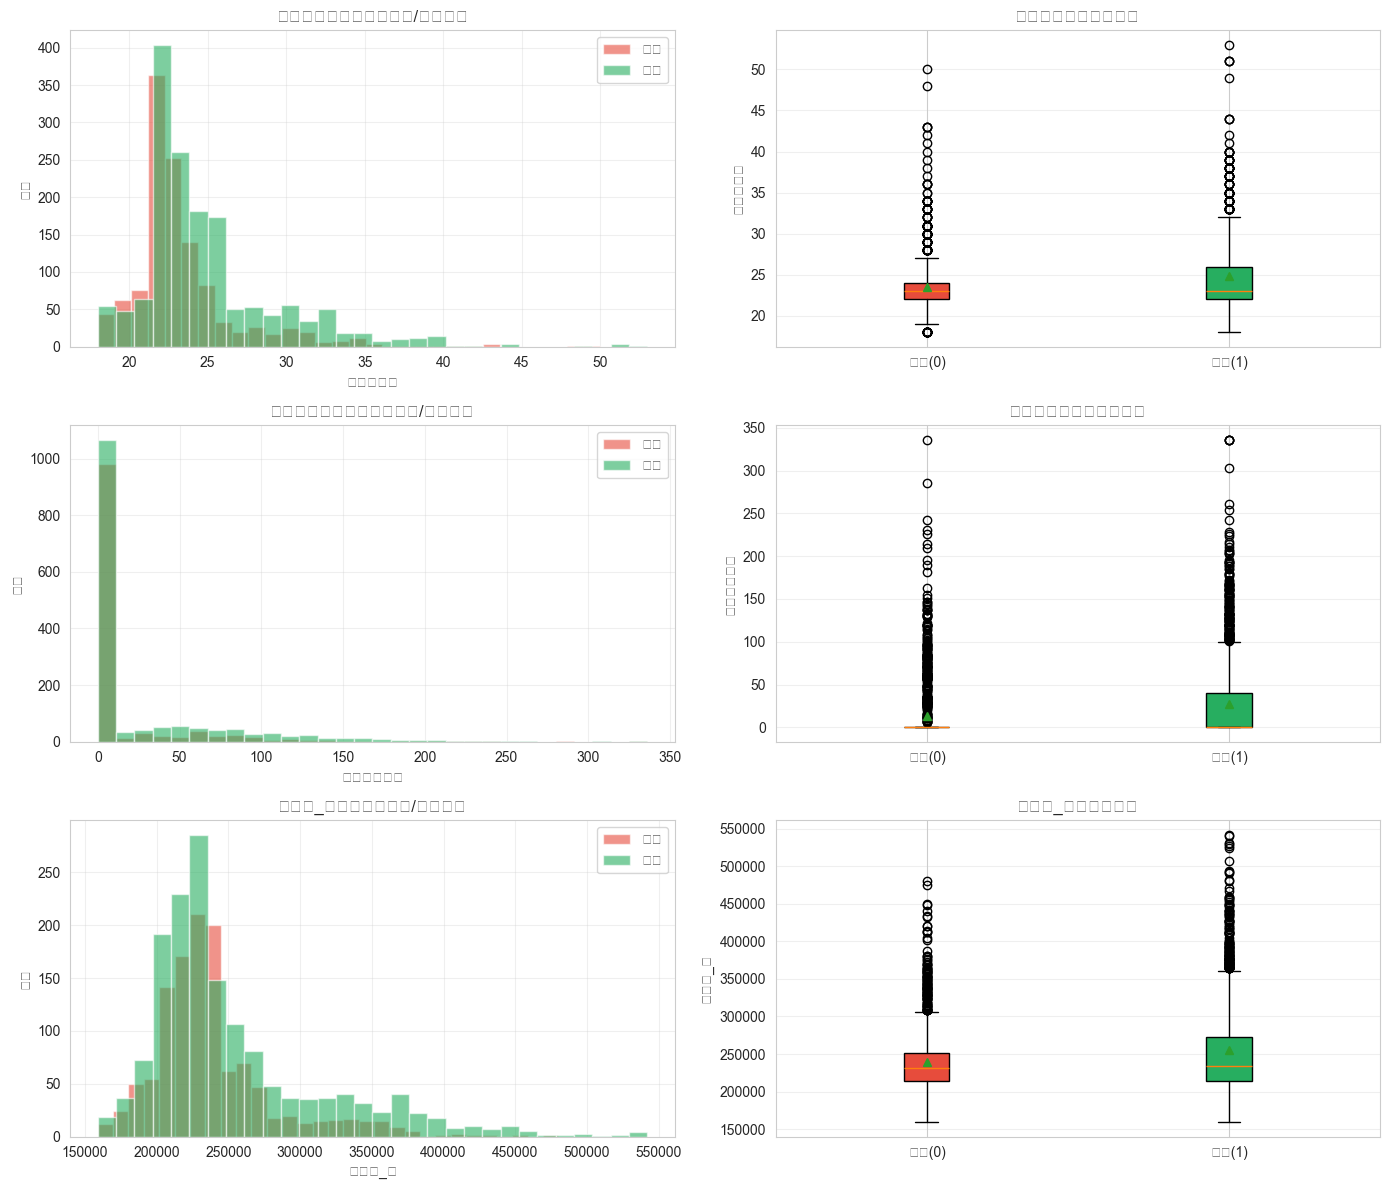

In [7]:
# 数値変数の分布と目的変数との関係
numeric_cols = ['入社時年齢', '前職経験月数', '初任給_円']

fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 12))

for idx, col in enumerate(numeric_cols):
    # ヒストグラム
    ax1 = axes[idx, 0]
    ax1.hist(train_persona[train_persona[target_col]==0][col].dropna(), 
             alpha=0.6, label='退職', bins=30, color='#e74c3c')
    ax1.hist(train_persona[train_persona[target_col]==1][col].dropna(), 
             alpha=0.6, label='定着', bins=30, color='#27ae60')
    ax1.set_xlabel(col)
    ax1.set_ylabel('度数')
    ax1.set_title(f'{col}の分布（定着/退職別）')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # 箱ひげ図
    ax2 = axes[idx, 1]
    data_to_plot = [
        train_persona[train_persona[target_col]==0][col].dropna(),
        train_persona[train_persona[target_col]==1][col].dropna()
    ]
    bp = ax2.boxplot(data_to_plot, labels=['退職(0)', '定着(1)'],
                     patch_artist=True, showmeans=True)
    bp['boxes'][0].set_facecolor('#e74c3c')
    bp['boxes'][1].set_facecolor('#27ae60')
    ax2.set_ylabel(col)
    ax2.set_title(f'{col}の箱ひげ図')
    ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# 数値変数の基本統計量（定着/退職別）
print("="*80)
print("数値変数の基本統計量（定着/退職別）")
print("="*80)

for col in numeric_cols:
    print(f"\n【{col}】")
    print("-" * 60)
    stats_df = train_persona.groupby(target_col)[col].describe()
    print(stats_df.round(2))

数値変数の基本統計量（定着/退職別）

【入社時年齢】
------------------------------------------------------------
           count   mean   std   min   25%   50%   75%   max
10年定着ラベル                                                   
0         1202.0  23.57  3.45  18.0  22.0  23.0  24.0  50.0
1         1559.0  24.80  4.51  18.0  22.0  23.0  26.0  53.0

【前職経験月数】
------------------------------------------------------------
           count   mean    std  min  25%  50%   75%    max
10年定着ラベル                                                  
0         1202.0  13.78  35.87  0.0  0.0  0.0   0.0  336.0
1         1559.0  26.73  50.06  0.0  0.0  0.0  40.0  336.0

【初任給_円】
------------------------------------------------------------
           count       mean       std       min       25%       50%       75%  \
10年定着ラベル                                                                        
0         1202.0  239801.16  44782.40  159000.0  214000.0  231000.0  251000.0   
1         1559.0  254722.90  62921.66  159000.0  21

## 4. 月次データの探索的分析

時系列パターンと定着・退職社員の違いを分析します。

In [9]:
# 月次データに目的変数を結合
train_monthly_labeled = train_monthly.merge(
    train_persona[['社員ID', target_col]], 
    on='社員ID', 
    how='left'
)

print(f"月次データに目的変数を結合: {train_monthly_labeled.shape}")

月次データに目的変数を結合: (65754, 30)


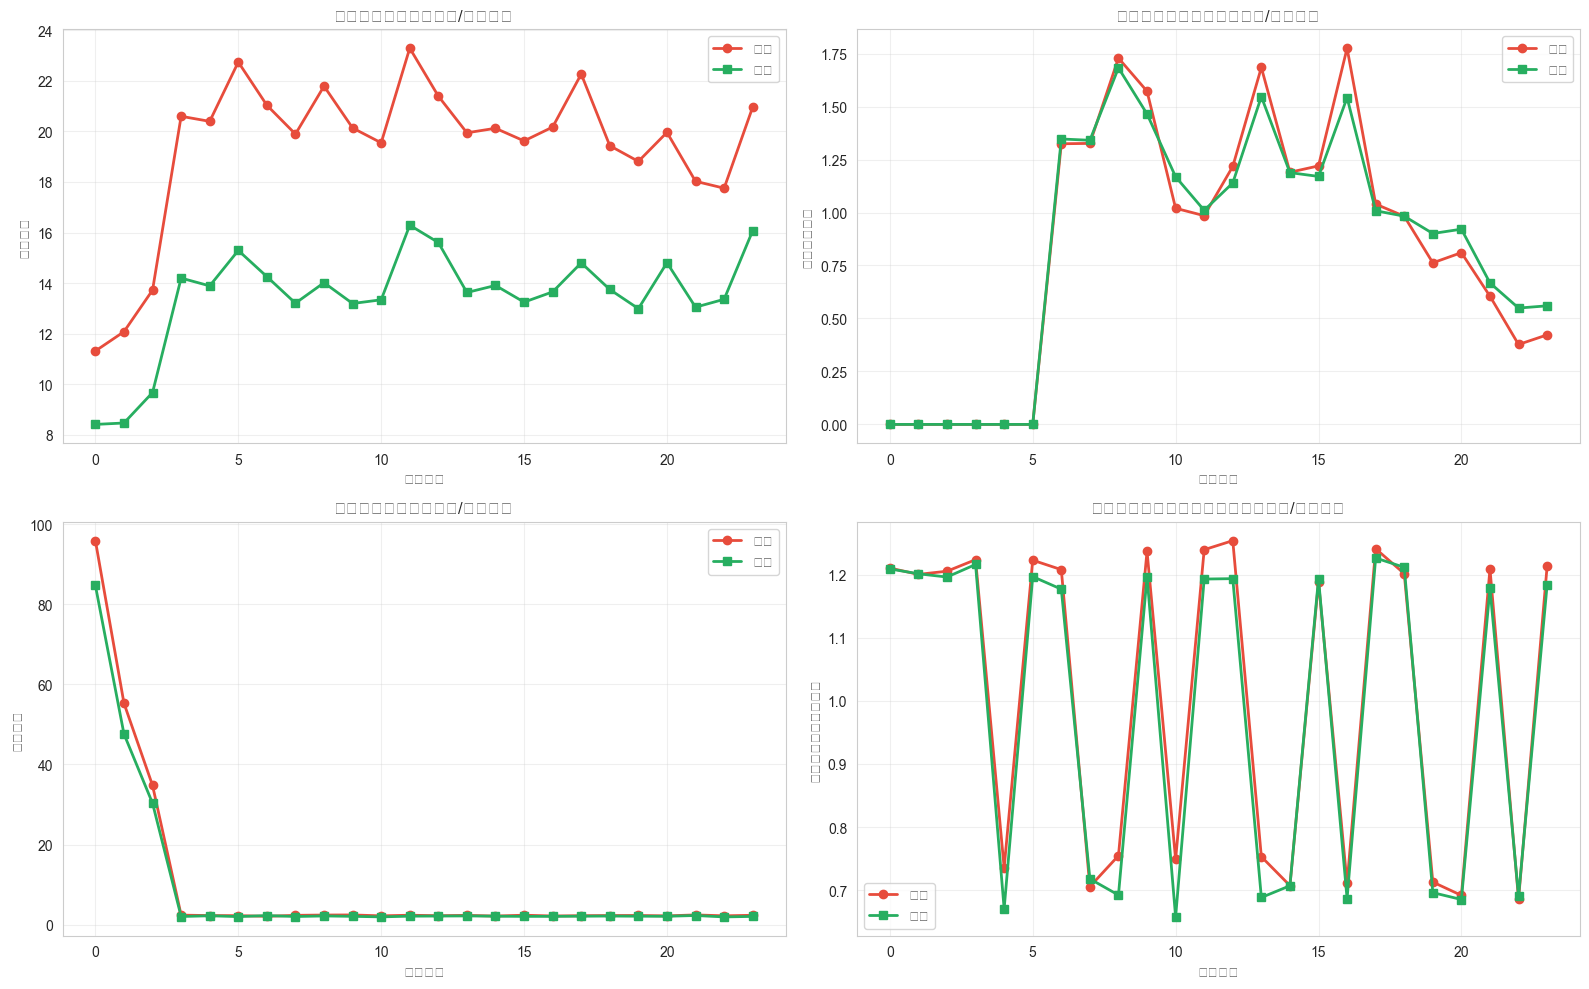

In [10]:
# 主要な月次変数の時系列パターン
monthly_numeric_cols = ['残業時間', '有給取得日数', '研修時間', '上司との面談実施回数']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(monthly_numeric_cols):
    ax = axes[idx]
    
    # 定着・退職別に経過月数ごとの平均値を計算
    time_series_data = train_monthly_labeled.groupby(['経過月数', target_col])[col].mean().unstack()
    
    # プロット
    if 0 in time_series_data.columns:
        ax.plot(time_series_data.index, time_series_data[0], 
                marker='o', label='退職', color='#e74c3c', linewidth=2)
    if 1 in time_series_data.columns:
        ax.plot(time_series_data.index, time_series_data[1], 
                marker='s', label='定着', color='#27ae60', linewidth=2)
    
    ax.set_xlabel('経過月数')
    ax.set_ylabel(col)
    ax.set_title(f'{col}の推移（定着/退職別）')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

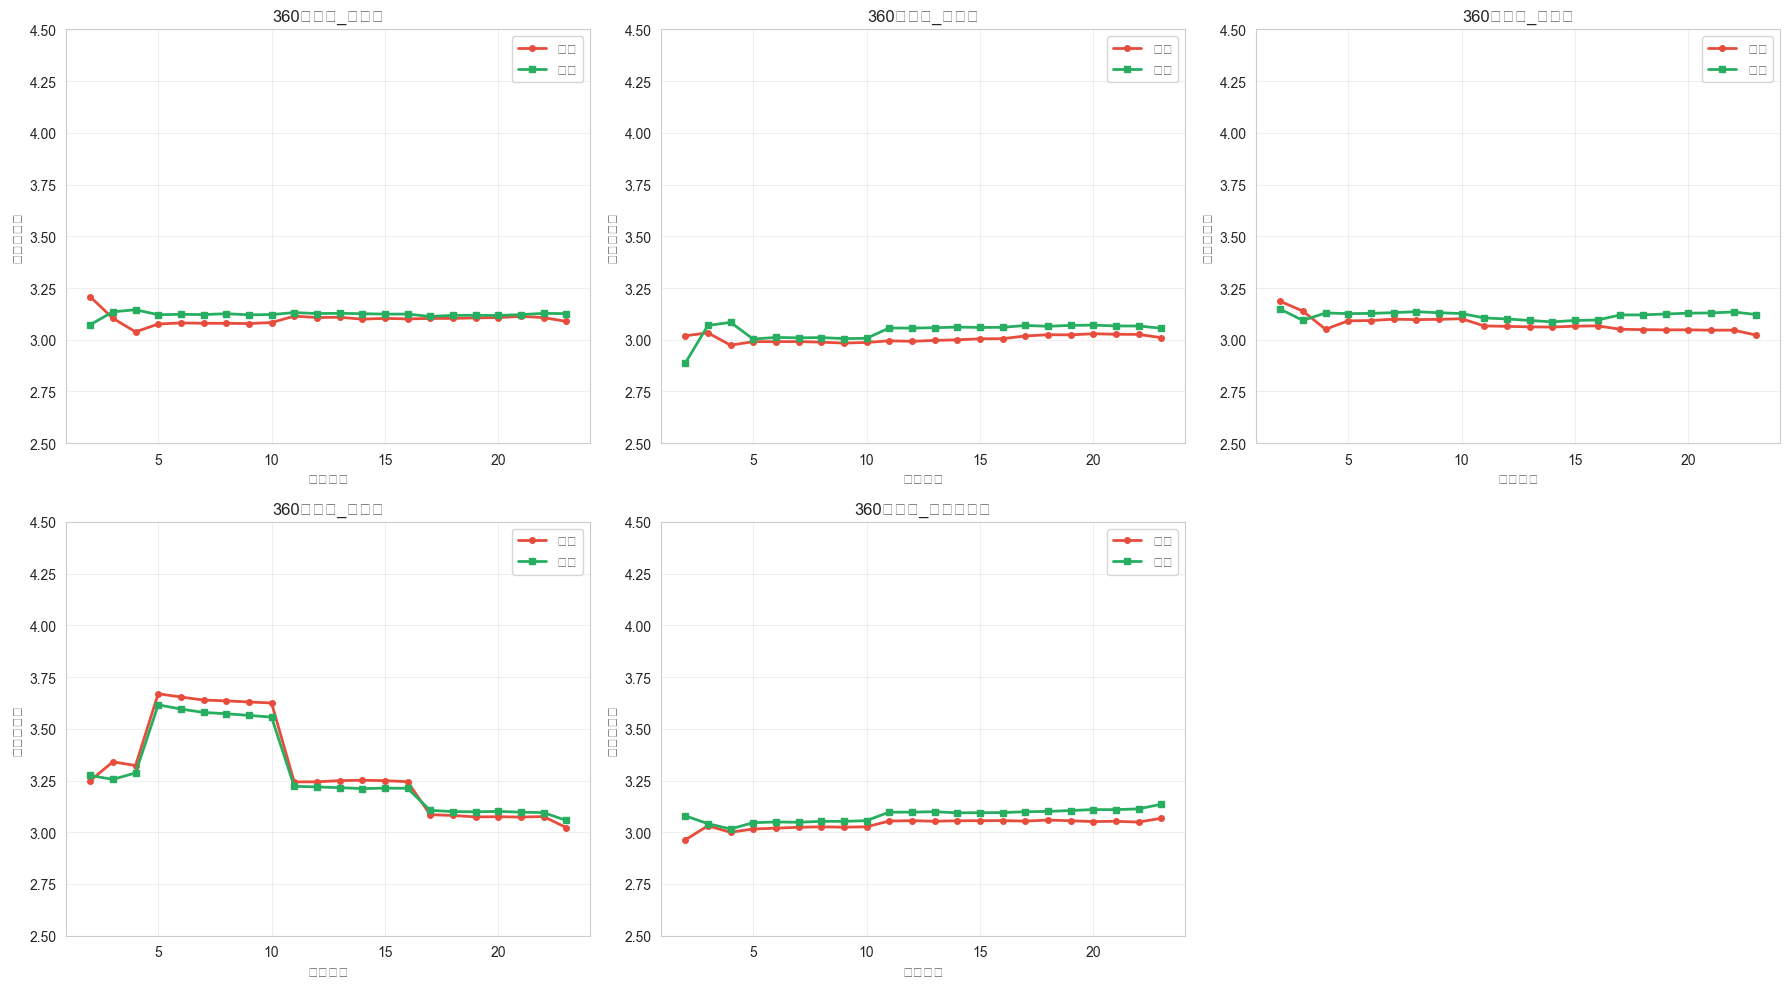

In [11]:
# 360度評価の時系列パターン
evaluation_cols = [
    '360度評価_親和度', '360度評価_信頼度', 
    '360度評価_主体度', '360度評価_学習度', '360度評価_共有貢献度'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(evaluation_cols):
    ax = axes[idx]
    
    # 定着・退職別に経過月数ごとの平均値を計算
    time_series_data = train_monthly_labeled.groupby(['経過月数', target_col])[col].mean().unstack()
    
    # プロット
    if 0 in time_series_data.columns:
        ax.plot(time_series_data.index, time_series_data[0], 
                marker='o', label='退職', color='#e74c3c', linewidth=2, markersize=4)
    if 1 in time_series_data.columns:
        ax.plot(time_series_data.index, time_series_data[1], 
                marker='s', label='定着', color='#27ae60', linewidth=2, markersize=4)
    
    ax.set_xlabel('経過月数')
    ax.set_ylabel('評価スコア')
    ax.set_title(col)
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim([2.5, 4.5])  # 評価は1-5の範囲

# 最後のサブプロットを非表示
axes[-1].axis('off')

plt.tight_layout()
plt.show()

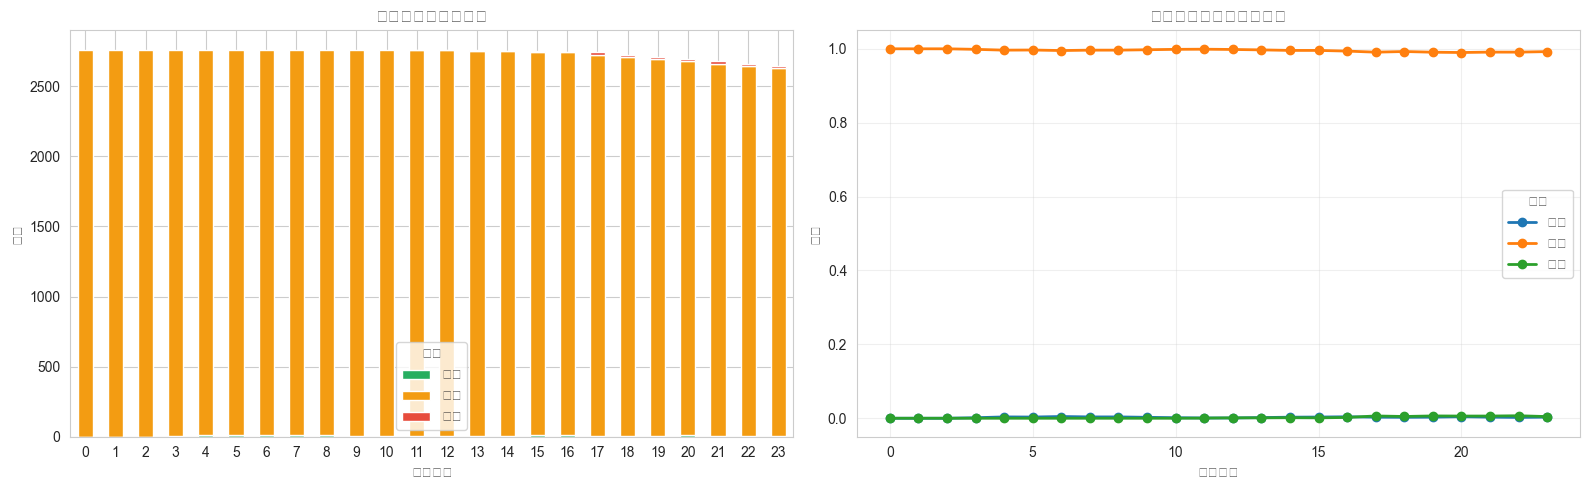

In [12]:
# 月末在籍状態の推移
status_pivot = train_monthly_labeled.groupby(['経過月数', '月末在籍状態']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 積み上げ棒グラフ
status_pivot.plot(kind='bar', stacked=True, ax=axes[0], 
                  color=['#27ae60', '#f39c12', '#e74c3c'])
axes[0].set_xlabel('経過月数')
axes[0].set_ylabel('人数')
axes[0].set_title('月末在籍状態の推移')
axes[0].legend(title='状態')
axes[0].tick_params(axis='x', rotation=0)

# 割合の推移
status_ratio = status_pivot.div(status_pivot.sum(axis=1), axis=0)
status_ratio.plot(kind='line', ax=axes[1], marker='o', linewidth=2)
axes[1].set_xlabel('経過月数')
axes[1].set_ylabel('割合')
axes[1].set_title('月末在籍状態の割合推移')
axes[1].legend(title='状態')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. 相関分析

数値変数間の相関と目的変数との相関を確認します。

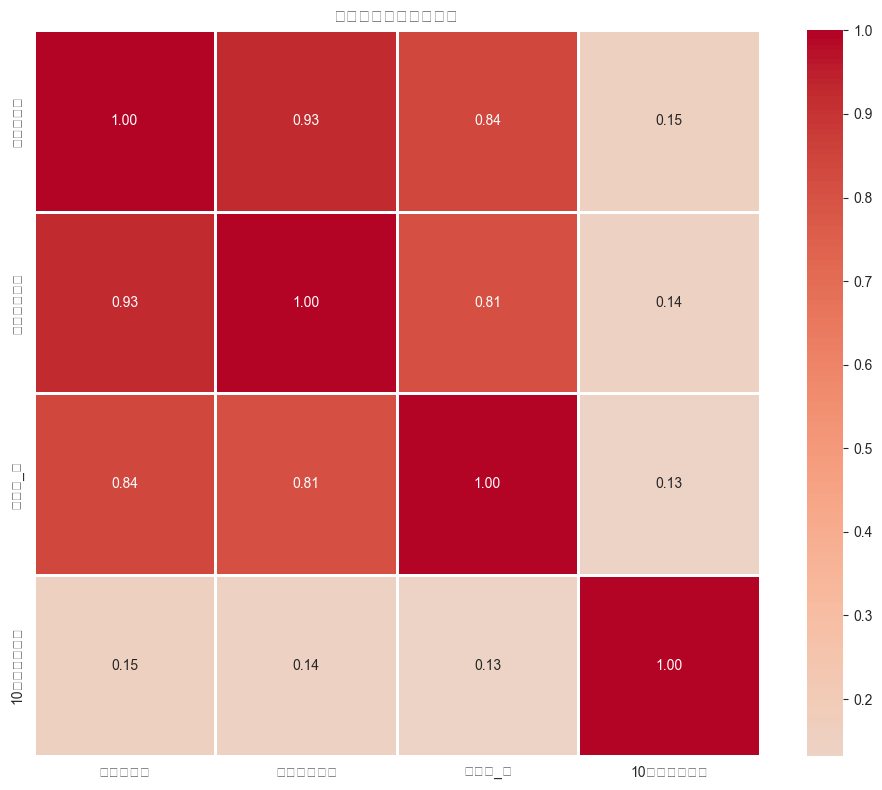


目的変数（10年定着ラベル）との相関
入社時年齢                         :  0.1487
前職経験月数                        :  0.1430
初任給_円                         :  0.1316


In [13]:
# 属性データの数値カラムの相関行列
numeric_persona_cols = train_persona.select_dtypes(include=[np.number]).columns.tolist()

# 相関行列を計算
corr_matrix = train_persona[numeric_persona_cols].corr()

# ヒートマップで可視化
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, ax=ax)
ax.set_title('属性データの相関行列')
plt.tight_layout()
plt.show()

# 目的変数との相関が高い変数
print("\n目的変数（10年定着ラベル）との相関")
print("="*60)
target_corr = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)
for col, corr_val in target_corr.items():
    print(f"{col:30s}: {corr_val:7.4f}")

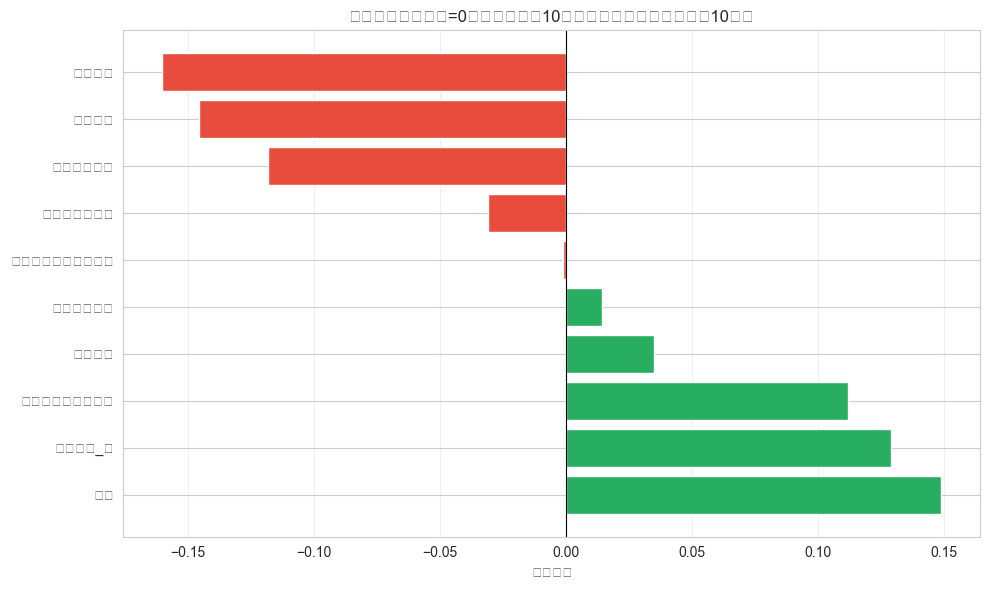


入社月の各指標と目的変数の相関（上位15件）
年齢                                 :  0.1487
月例給与_円                             :  0.1287
担当プロジェクト数                          :  0.1117
欠勤日数                               :  0.0347
情報共有件数                             :  0.0143
上司との面談実施回数                         : -0.0013
顧客満足度評価                            : -0.0310
在宅勤務日数                             : -0.1185
研修時間                               : -0.1455
残業時間                               : -0.1602
経過月数                               :     nan
360度評価_親和度                         :     nan
360度評価_信頼度                         :     nan
360度評価_主体度                         :     nan
360度評価_学習度                         :     nan


In [14]:
# 経過月数0（入社月）のデータと目的変数の相関
month0_data = train_monthly_labeled[train_monthly_labeled['経過月数'] == 0].copy()

# 数値カラムのみ抽出
month0_numeric = month0_data.select_dtypes(include=[np.number])

if target_col in month0_numeric.columns:
    month0_corr = month0_numeric.corr()[target_col].drop(target_col).sort_values(ascending=False)
    
    # 上位10件を可視化
    fig, ax = plt.subplots(figsize=(10, 6))
    top10_corr = month0_corr.head(10)
    colors = ['#27ae60' if x > 0 else '#e74c3c' for x in top10_corr.values]
    ax.barh(range(len(top10_corr)), top10_corr.values, color=colors)
    ax.set_yticks(range(len(top10_corr)))
    ax.set_yticklabels(top10_corr.index)
    ax.set_xlabel('相関係数')
    ax.set_title('入社月（経過月数=0）の各指標と10年定着ラベルの相関（上位10件）')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n入社月の各指標と目的変数の相関（上位15件）")
    print("="*60)
    for col, corr_val in month0_corr.head(15).items():
        print(f"{col:35s}: {corr_val:7.4f}")

In [15]:
# 6. テキストデータの分析

print("="*80)
print("テキストデータの統計分析")
print("="*80)

text_cols = ['入社時メモ', '上司からのフィードバック', '同僚からのフィードバック']

# 各テキストカラムの基本統計
for col in text_cols:
    print(f"\n【{col}】")
    print("-" * 60)
    
    # 欠損率
    missing_rate = train_persona[col].isnull().sum() / len(train_persona) * 100
    print(f"欠損率: {missing_rate:.2f}%")
    
    # 欠損でないデータのみ抽出
    valid_texts = train_persona[col].dropna()
    
    if len(valid_texts) > 0:
        # 文字数の統計
        char_counts = valid_texts.str.len()
        print(f"\n文字数統計:")
        print(f"  平均: {char_counts.mean():.1f}文字")
        print(f"  中央値: {char_counts.median():.0f}文字")
        print(f"  最小: {char_counts.min()}文字")
        print(f"  最大: {char_counts.max()}文字")
        
        # 定着/退職別の文字数比較
        char_by_target = train_persona.groupby(target_col)[col].apply(
            lambda x: x.dropna().str.len().mean()
        )
        print(f"\n定着/退職別の平均文字数:")
        print(f"  退職(0): {char_by_target[0]:.1f}文字")
        print(f"  定着(1): {char_by_target[1]:.1f}文字")
        print(f"  差分: {char_by_target[1] - char_by_target[0]:.1f}文字")

テキストデータの統計分析

【入社時メモ】
------------------------------------------------------------
欠損率: 0.00%

文字数統計:
  平均: 205.1文字
  中央値: 207文字
  最小: 44文字
  最大: 261文字

定着/退職別の平均文字数:
  退職(0): 205.8文字
  定着(1): 204.5文字
  差分: -1.2文字

【上司からのフィードバック】
------------------------------------------------------------
欠損率: 0.00%

文字数統計:
  平均: 459.4文字
  中央値: 459文字
  最小: 316文字
  最大: 617文字

定着/退職別の平均文字数:
  退職(0): 459.3文字
  定着(1): 459.5文字
  差分: 0.2文字

【同僚からのフィードバック】
------------------------------------------------------------
欠損率: 0.00%

文字数統計:
  平均: 224.0文字
  中央値: 222文字
  最小: 149文字
  最大: 325文字

定着/退職別の平均文字数:
  退職(0): 223.6文字
  定着(1): 224.3文字
  差分: 0.7文字


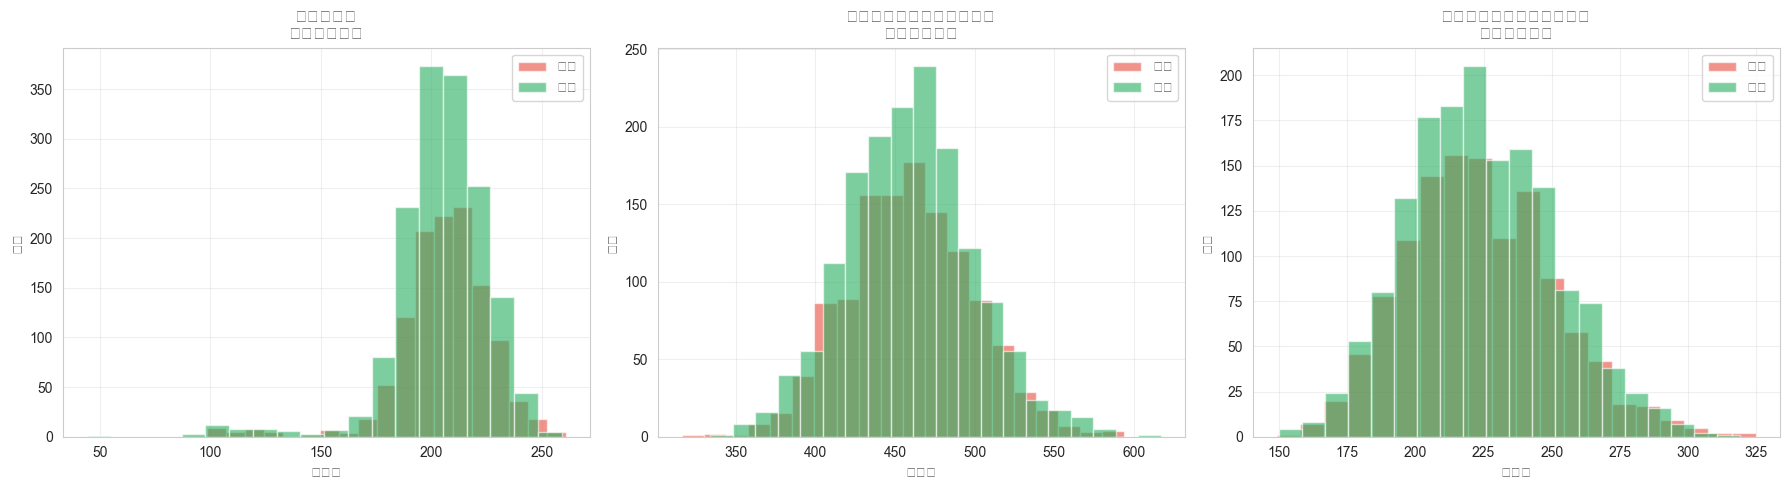

In [16]:
# テキストデータの可視化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(text_cols):
    ax = axes[idx]
    
    # 欠損でないデータのみ抽出
    valid_data = train_persona[[col, target_col]].dropna()
    
    if len(valid_data) > 0:
        # 文字数を計算
        valid_data['char_count'] = valid_data[col].str.len()
        
        # ヒストグラム
        ax.hist(valid_data[valid_data[target_col]==0]['char_count'], 
                alpha=0.6, label='退職', bins=20, color='#e74c3c')
        ax.hist(valid_data[valid_data[target_col]==1]['char_count'], 
                alpha=0.6, label='定着', bins=20, color='#27ae60')
        ax.set_xlabel('文字数')
        ax.set_ylabel('度数')
        ax.set_title(f'{col}\n文字数の分布')
        ax.legend()
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 月次カテゴリ変数の変化パターン

In [17]:
# 月次データで変化パターンを分析
print("="*80)
print("月次カテゴリ変数の変化パターン")
print("="*80)

# 分析対象のカテゴリ変数
change_cols = ['部署ID', '職種', '役割', '等級', '勤務地', '上司ID']

# 各社員の変更回数を計算
change_stats = []

for col in change_cols:
    # 各社員の変更回数をカウント
    changes_per_employee = train_monthly_labeled.sort_values(['社員ID', '経過月数']).groupby('社員ID')[col].apply(
        lambda x: (x != x.shift()).sum() - 1  # -1は初回を除く
    )
    
    # 目的変数と結合
    changes_with_target = pd.DataFrame({
        '変更回数': changes_per_employee
    }).merge(train_persona[['社員ID', target_col]], on='社員ID', how='left')
    
    # 定着/退職別の統計
    stats_by_target = changes_with_target.groupby(target_col)['変更回数'].agg(['mean', 'median', 'max'])
    
    print(f"\n【{col}】")
    print("-" * 60)
    print(f"全体の平均変更回数: {changes_per_employee.mean():.2f}回")
    print(f"退職者の平均: {stats_by_target.loc[0, 'mean']:.2f}回")
    print(f"定着者の平均: {stats_by_target.loc[1, 'mean']:.2f}回")
    print(f"差分: {stats_by_target.loc[1, 'mean'] - stats_by_target.loc[0, 'mean']:.2f}回")
    
    change_stats.append({
        '変数': col,
        '退職者平均': stats_by_target.loc[0, 'mean'],
        '定着者平均': stats_by_target.loc[1, 'mean'],
        '差分': stats_by_target.loc[1, 'mean'] - stats_by_target.loc[0, 'mean']
    })

# 結果をDataFrame化
change_stats_df = pd.DataFrame(change_stats)

月次カテゴリ変数の変化パターン

【部署ID】
------------------------------------------------------------
全体の平均変更回数: 0.26回
退職者の平均: 0.24回
定着者の平均: 0.27回
差分: 0.03回



【職種】
------------------------------------------------------------
全体の平均変更回数: 0.01回
退職者の平均: 0.01回
定着者の平均: 0.01回
差分: -0.00回

【役割】
------------------------------------------------------------
全体の平均変更回数: 0.00回
退職者の平均: 0.00回
定着者の平均: 0.00回
差分: 0.00回



【等級】
------------------------------------------------------------
全体の平均変更回数: 0.00回
退職者の平均: 0.00回
定着者の平均: 0.00回
差分: 0.00回

【勤務地】
------------------------------------------------------------
全体の平均変更回数: 0.02回
退職者の平均: 0.02回
定着者の平均: 0.02回
差分: 0.00回



【上司ID】
------------------------------------------------------------
全体の平均変更回数: 0.35回
退職者の平均: 0.33回
定着者の平均: 0.36回
差分: 0.03回


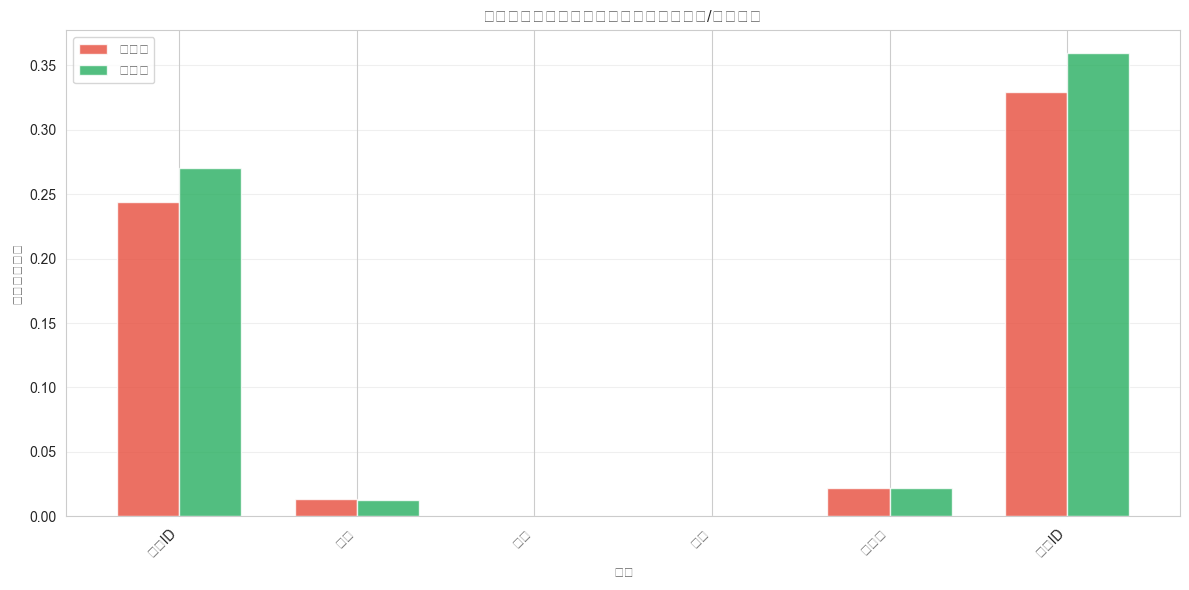

In [18]:
# 変化パターンの可視化
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(change_stats_df))
width = 0.35

ax.bar(x - width/2, change_stats_df['退職者平均'], width, 
       label='退職者', color='#e74c3c', alpha=0.8)
ax.bar(x + width/2, change_stats_df['定着者平均'], width,
       label='定着者', color='#27ae60', alpha=0.8)

ax.set_xlabel('変数')
ax.set_ylabel('平均変更回数')
ax.set_title('月次カテゴリ変数の平均変更回数（定着/退職別）')
ax.set_xticks(x)
ax.set_xticklabels(change_stats_df['変数'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. 時系列特徴量の変化点・トレンド分析

In [19]:
# 時系列トレンドと変化点の分析
from scipy import stats

print("="*80)
print("時系列特徴量のトレンド分析")
print("="*80)

# 分析対象の数値変数
trend_cols = ['残業時間', '研修時間', '上司との面談実施回数', '月例給与_円']

# 各社員の時系列トレンド（線形回帰の傾き）を計算
trend_results = []

for col in trend_cols:
    # 各社員ごとに線形回帰の傾きを計算
    def calc_trend(group):
        valid_data = group[['経過月数', col]].dropna()
        if len(valid_data) >= 3:  # 最低3データポイント必要
            slope, intercept, r_value, p_value, std_err = stats.linregress(
                valid_data['経過月数'], valid_data[col]
            )
            return pd.Series({
                '傾き': slope,
                'R2': r_value**2,
                '初期値': valid_data[col].iloc[0] if len(valid_data) > 0 else np.nan,
                '最終値': valid_data[col].iloc[-1] if len(valid_data) > 0 else np.nan
            })
        return pd.Series({'傾き': np.nan, 'R2': np.nan, '初期値': np.nan, '最終値': np.nan})
    
    trends = train_monthly_labeled.groupby('社員ID').apply(calc_trend).reset_index()
    
    # 目的変数と結合
    trends = trends.merge(train_persona[['社員ID', target_col]], on='社員ID', how='left')
    
    # 定着/退職別の統計
    stats_by_target = trends.groupby(target_col)['傾き'].agg(['mean', 'median', 'std'])
    
    print(f"\n【{col}】")
    print("-" * 60)
    print(f"退職者の平均傾き: {stats_by_target.loc[0, 'mean']:.4f}")
    print(f"定着者の平均傾き: {stats_by_target.loc[1, 'mean']:.4f}")
    print(f"差分: {stats_by_target.loc[1, 'mean'] - stats_by_target.loc[0, 'mean']:.4f}")
    
    trend_results.append({
        '変数': col,
        '退職者傾き': stats_by_target.loc[0, 'mean'],
        '定着者傾き': stats_by_target.loc[1, 'mean']
    })

trend_results_df = pd.DataFrame(trend_results)

時系列特徴量のトレンド分析



【残業時間】
------------------------------------------------------------
退職者の平均傾き: 0.2408
定着者の平均傾き: 0.1429
差分: -0.0980



【研修時間】
------------------------------------------------------------
退職者の平均傾き: -1.7759
定着者の平均傾き: -1.4753
差分: 0.3006



【上司との面談実施回数】
------------------------------------------------------------
退職者の平均傾き: -0.0087
定着者の平均傾き: -0.0081
差分: 0.0006



【月例給与_円】
------------------------------------------------------------
退職者の平均傾き: 403.4597
定着者の平均傾き: 459.6564
差分: 56.1967


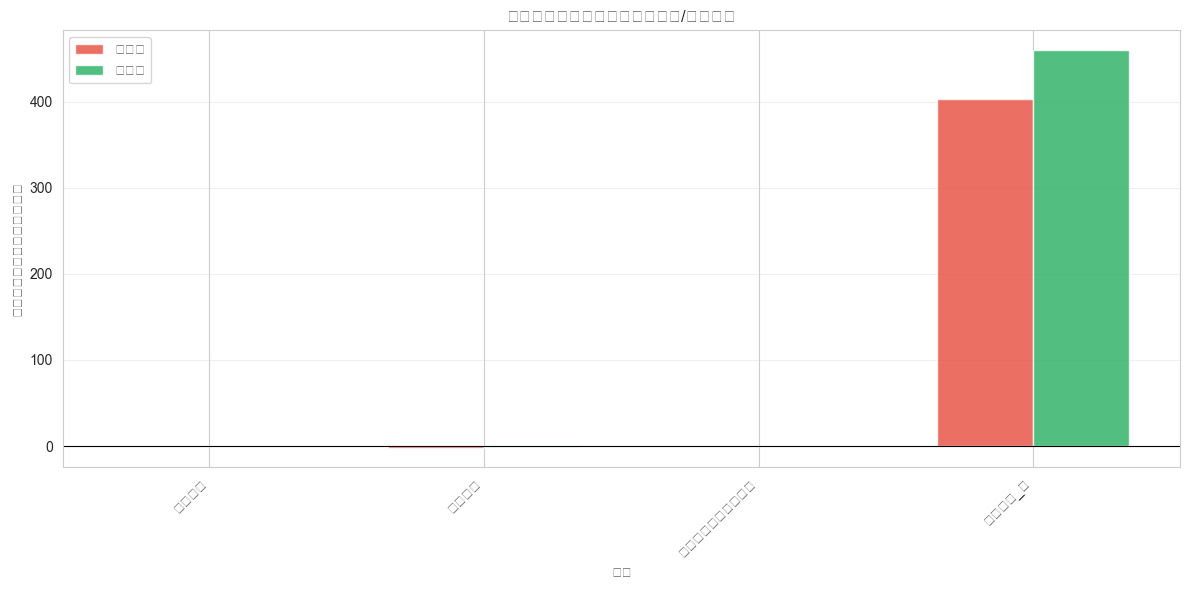


✅ 正の傾き = 時間経過とともに増加
❌ 負の傾き = 時間経過とともに減少


In [20]:
# トレンドの可視化
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(trend_results_df))
width = 0.35

ax.bar(x - width/2, trend_results_df['退職者傾き'], width, 
       label='退職者', color='#e74c3c', alpha=0.8)
ax.bar(x + width/2, trend_results_df['定着者傾き'], width,
       label='定着者', color='#27ae60', alpha=0.8)

ax.set_xlabel('変数')
ax.set_ylabel('平均傾き（月あたりの変化）')
ax.set_title('時系列特徴量のトレンド（定着/退職別）')
ax.set_xticks(x)
ax.set_xticklabels(trend_results_df['変数'], rotation=45, ha='right')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ 正の傾き = 時間経過とともに増加")
print("❌ 負の傾き = 時間経過とともに減少")

## 9. 欠損パターンの特徴化

In [21]:
# 欠損パターンの分析
print("="*80)
print("高欠損変数の欠損パターン分析")
print("="*80)

# 高欠損変数
high_missing_cols = [
    '360度評価_親和度',
    '360度評価_信頼度',
    '顧客満足度評価',
    '担当プロジェクト数'
]

# 各社員の欠損率を計算
missing_rate_per_employee = {}

for col in high_missing_cols:
    # 各社員の0-23ヶ月間の欠損率
    missing_rates = train_monthly_labeled.groupby('社員ID')[col].apply(
        lambda x: x.isnull().sum() / len(x)
    )
    
    # 目的変数と結合
    missing_with_target = pd.DataFrame({
        '欠損率': missing_rates
    }).merge(train_persona[['社員ID', target_col]], on='社員ID', how='left')
    
    # 定着/退職別の統計
    stats_by_target = missing_with_target.groupby(target_col)['欠損率'].agg(['mean', 'median'])
    
    print(f"\n【{col}】")
    print("-" * 60)
    print(f"退職者の平均欠損率: {stats_by_target.loc[0, 'mean']*100:.2f}%")
    print(f"定着者の平均欠損率: {stats_by_target.loc[1, 'mean']*100:.2f}%")
    print(f"差分: {(stats_by_target.loc[1, 'mean'] - stats_by_target.loc[0, 'mean'])*100:.2f}%ポイント")
    
    missing_rate_per_employee[col] = missing_with_target

高欠損変数の欠損パターン分析

【360度評価_親和度】
------------------------------------------------------------
退職者の平均欠損率: 21.09%
定着者の平均欠損率: 20.45%
差分: -0.64%ポイント

【360度評価_信頼度】
------------------------------------------------------------
退職者の平均欠損率: 21.09%
定着者の平均欠損率: 20.45%
差分: -0.64%ポイント



【顧客満足度評価】
------------------------------------------------------------
退職者の平均欠損率: 58.64%
定着者の平均欠損率: 70.41%
差分: 11.77%ポイント

【担当プロジェクト数】
------------------------------------------------------------
退職者の平均欠損率: 34.44%
定着者の平均欠損率: 57.31%
差分: 22.87%ポイント


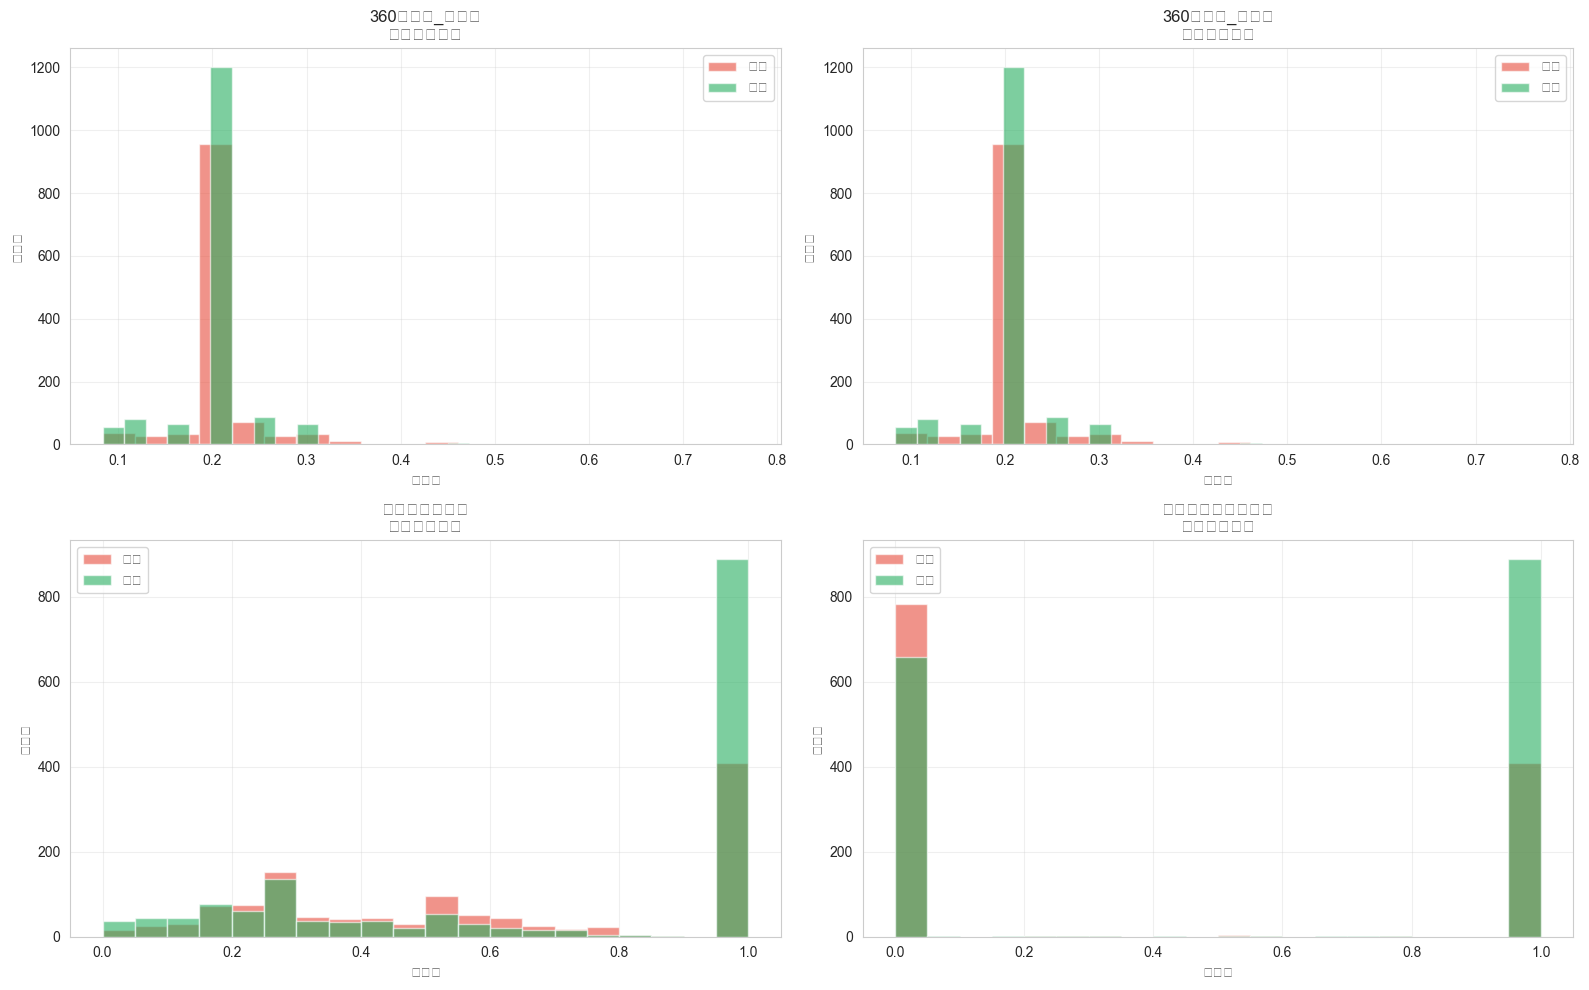

In [22]:
# 欠損パターンの可視化
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(high_missing_cols):
    ax = axes[idx]
    data = missing_rate_per_employee[col]
    
    # ヒストグラム
    ax.hist(data[data[target_col]==0]['欠損率'], 
            alpha=0.6, label='退職', bins=20, color='#e74c3c')
    ax.hist(data[data[target_col]==1]['欠損率'], 
            alpha=0.6, label='定着', bins=20, color='#27ae60')
    ax.set_xlabel('欠損率')
    ax.set_ylabel('社員数')
    ax.set_title(f'{col}\n欠損率の分布')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

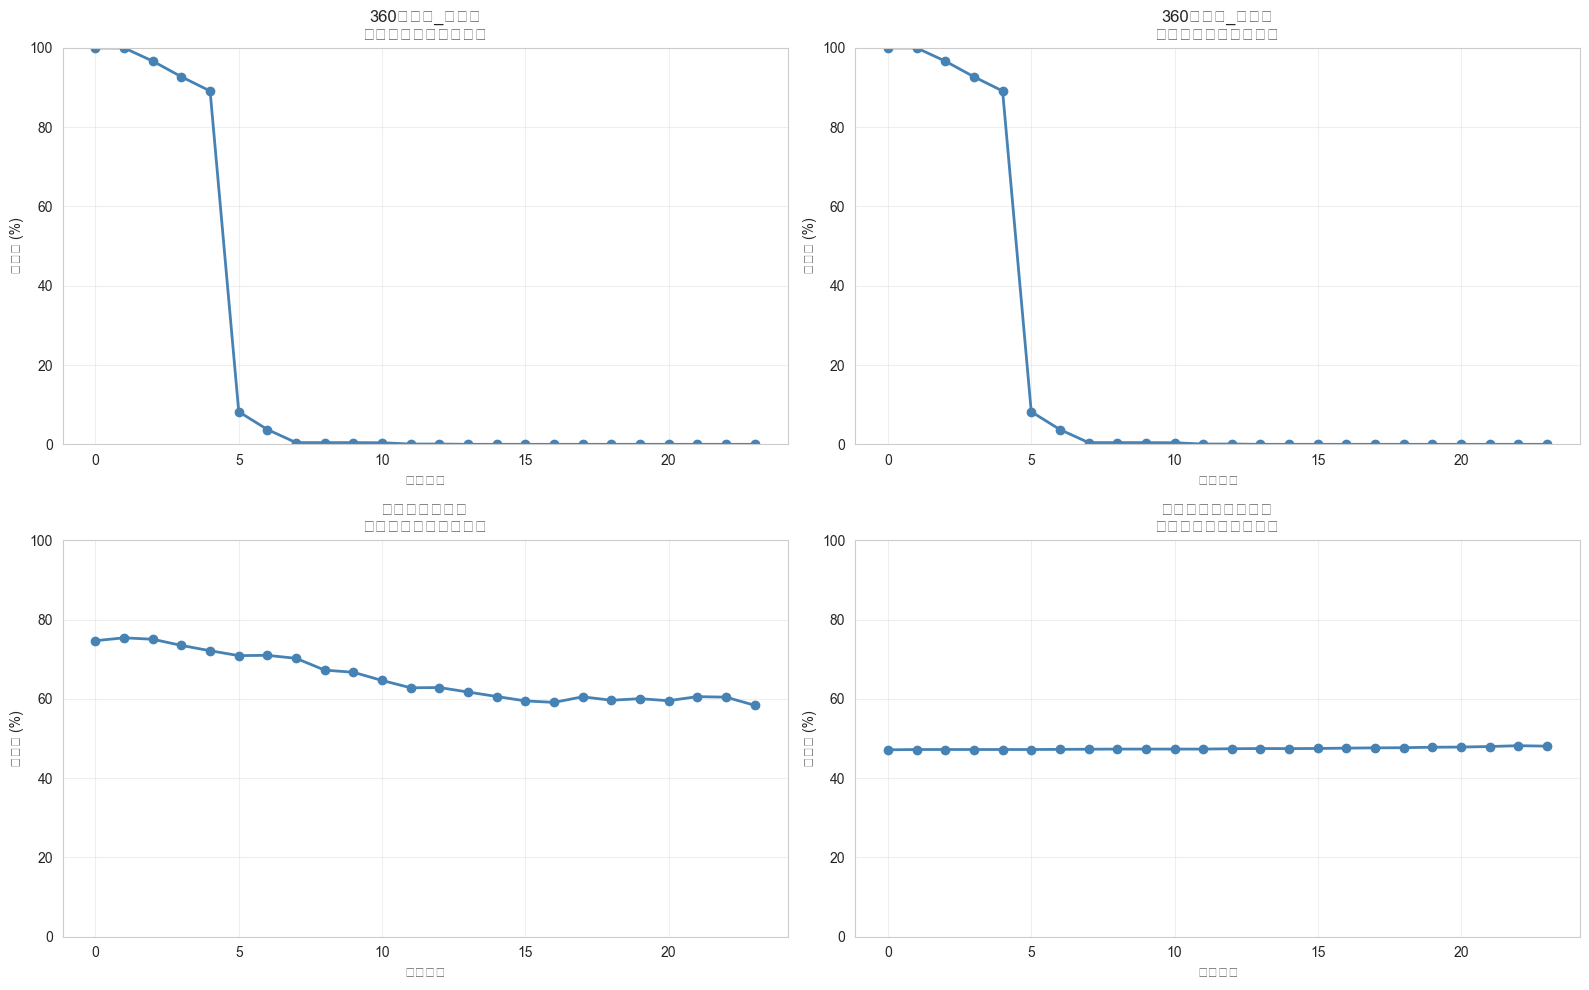


✅ 欠損率が時間経過とともに減少 = 評価・業務が始まるタイミング


In [23]:
# 経過月数ごとの欠損率の推移
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(high_missing_cols):
    ax = axes[idx]
    
    # 経過月数ごとの欠損率
    missing_by_month = train_monthly_labeled.groupby('経過月数')[col].apply(
        lambda x: x.isnull().sum() / len(x) * 100
    )
    
    ax.plot(missing_by_month.index, missing_by_month.values, 
            marker='o', linewidth=2, color='steelblue')
    ax.set_xlabel('経過月数')
    ax.set_ylabel('欠損率 (%)')
    ax.set_title(f'{col}\n経過月数ごとの欠損率')
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 100])

plt.tight_layout()
plt.show()

print("\n✅ 欠損率が時間経過とともに減少 = 評価・業務が始まるタイミング")

## 10. Train/Testデータの分布比較（共変量シフトの検証）

TrainとTestは観測期間が異なる（Train: 2011-04〜2014-03入社、Test: 2014-04〜2017-03入社）。
既存レポートでは「時系列の偏り」がリスクとして言及されていたが、実際にどの変数がどの程度シフトしているかは未検証だった。
KS検定（数値変数）とカテゴリ割合の比較により、共変量シフトの有無を定量的に確認する。

In [24]:
# 属性データの数値変数：Train vs Test の分布比較（KS検定）
from scipy import stats

print("="*80)
print("属性データ数値変数のTrain/Test分布比較（KS検定）")
print("="*80)

numeric_cols = ['入社時年齢', '前職経験月数', '初任給_円']
ks_results = []
for col in numeric_cols:
    ks_stat, p_value = stats.ks_2samp(train_persona[col].dropna(), test_persona[col].dropna())
    ks_results.append({
        '変数': col, 'KS統計量': ks_stat, 'p値': p_value,
        'Train平均': train_persona[col].mean(), 'Test平均': test_persona[col].mean()
    })
    sig = "**シフトあり**" if p_value < 0.05 else "有意差なし"
    print(f"{col:12s}: KS={ks_stat:.4f}  p={p_value:.4e}  Train平均={train_persona[col].mean():10.1f}  "
          f"Test平均={test_persona[col].mean():10.1f}  [{sig}]")

ks_results_df = pd.DataFrame(ks_results)

属性データ数値変数のTrain/Test分布比較（KS検定）
入社時年齢       : KS=0.0197  p=6.7640e-01  Train平均=      24.3  Test平均=      24.5  [有意差なし]
前職経験月数      : KS=0.0135  p=9.6648e-01  Train平均=      21.1  Test平均=      22.6  [有意差なし]
初任給_円       : KS=0.2020  p=2.4354e-47  Train平均=  248226.7  Test平均=  262812.9  [**シフトあり**]


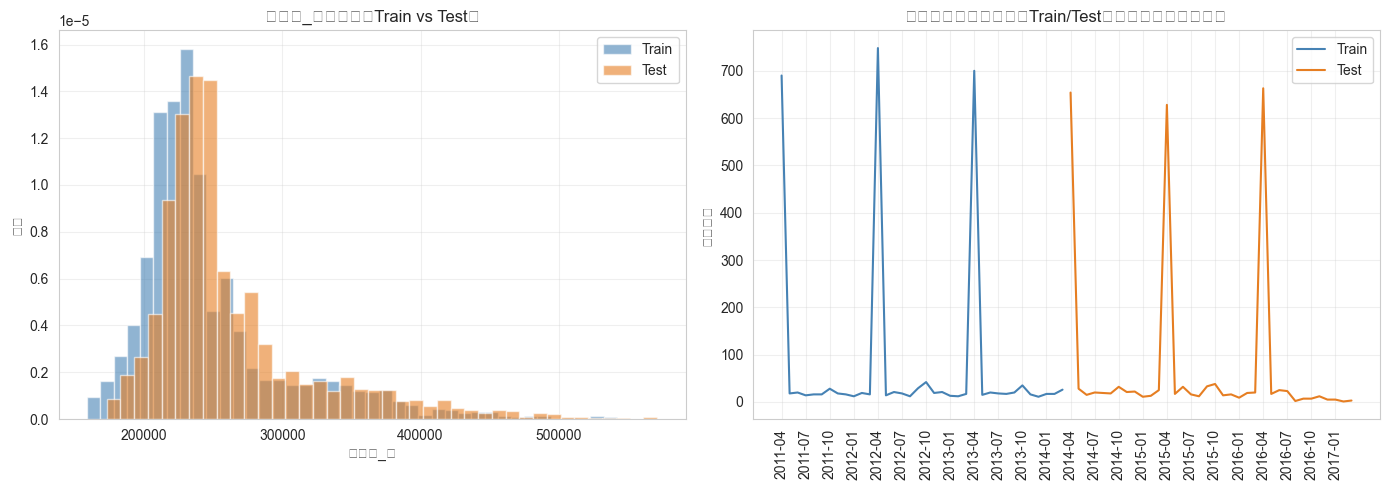

初任給_円の分布はTestの方が高い方向にシフトしている（賃金上昇 or 採用市場の変化の可能性）


In [25]:
# 初任給_円のTrain/Test分布可視化（最も差が大きい変数）
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_persona['初任給_円'], bins=40, alpha=0.6, label='Train', color='steelblue', density=True)
axes[0].hist(test_persona['初任給_円'], bins=40, alpha=0.6, label='Test', color='#e67e22', density=True)
axes[0].set_xlabel('初任給_円')
axes[0].set_ylabel('密度')
axes[0].set_title('初任給_円の分布（Train vs Test）')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 入社日（年月）ごとの入社者数推移
train_ym = pd.to_datetime(train_persona['入社日']).dt.to_period('M').value_counts().sort_index()
test_ym = pd.to_datetime(test_persona['入社日']).dt.to_period('M').value_counts().sort_index()
axes[1].plot(train_ym.index.astype(str), train_ym.values, label='Train', color='steelblue')
axes[1].plot(test_ym.index.astype(str), test_ym.values, label='Test', color='#e67e22')
axes[1].set_xticks(axes[1].get_xticks()[::3])
axes[1].tick_params(axis='x', rotation=90)
axes[1].set_ylabel('入社者数')
axes[1].set_title('月別入社者数の推移（Train/Test、観測期間が非連続）')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("初任給_円の分布はTestの方が高い方向にシフトしている（賃金上昇 or 採用市場の変化の可能性）")

In [26]:
# カテゴリカル変数：Train/Testの割合比較
print("="*80)
print("カテゴリカル変数のTrain/Test割合比較")
print("="*80)

cat_cols = ['入社区分', '最終学歴', '性別', '初期職種', '初期勤務地', '初期等級', '初期役割', '採用経路', '専攻分野']
cat_shift_results = []
for col in cat_cols:
    tr_ratio = train_persona[col].value_counts(normalize=True)
    te_ratio = test_persona[col].value_counts(normalize=True)
    both = pd.DataFrame({'Train割合': tr_ratio, 'Test割合': te_ratio}).fillna(0)
    max_diff = (both['Train割合'] - both['Test割合']).abs().max() * 100
    cat_shift_results.append({'変数': col, '最大割合差(pt)': max_diff})
    print(f"{col:10s}: カテゴリ間の最大割合差 = {max_diff:.2f}%pt")

cat_shift_df = pd.DataFrame(cat_shift_results).sort_values('最大割合差(pt)', ascending=False)

カテゴリカル変数のTrain/Test割合比較
入社区分      : カテゴリ間の最大割合差 = 0.52%pt
最終学歴      : カテゴリ間の最大割合差 = 1.78%pt
性別        : カテゴリ間の最大割合差 = 3.01%pt
初期職種      : カテゴリ間の最大割合差 = 1.14%pt
初期勤務地     : カテゴリ間の最大割合差 = 1.96%pt
初期等級      : カテゴリ間の最大割合差 = 0.56%pt
初期役割      : カテゴリ間の最大割合差 = 0.72%pt
採用経路      : カテゴリ間の最大割合差 = 0.92%pt
専攻分野      : カテゴリ間の最大割合差 = 0.87%pt


月次データ数値変数のTrain/Test分布比較（KS検定、0-23ヶ月）
残業時間        : KS=0.0169  p=3.3541e-08  Train平均=     16.01  Test平均=     15.46  [**シフトあり**]
研修時間        : KS=0.0024  p=9.9217e-01  Train平均=      9.16  Test平均=      9.07  [有意差なし]
月例給与_円      : KS=0.1735  p=0.0000e+00  Train平均= 285247.67  Test平均= 300757.09  [**シフトあり**]
在宅勤務日数      : KS=0.0111  p=9.0322e-04  Train平均=      5.37  Test平均=      5.37  [**シフトあり**]
有給取得日数      : KS=0.0049  p=4.4140e-01  Train平均=      0.84  Test平均=      0.85  [有意差なし]
欠勤日数        : KS=0.0010  p=1.0000e+00  Train平均=      0.07  Test平均=      0.07  [有意差なし]
情報共有件数      : KS=0.0084  p=2.2661e-02  Train平均=      1.01  Test平均=      1.03  [**シフトあり**]


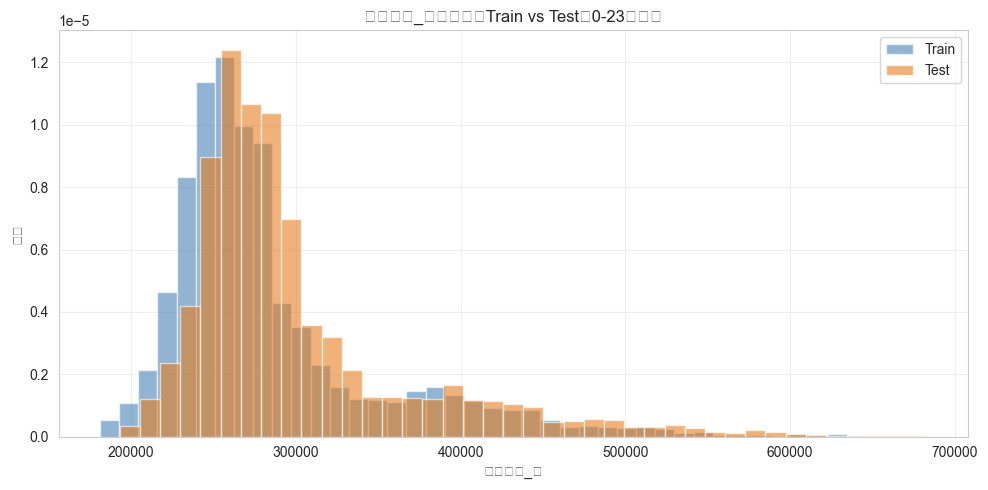


給与関連の変数（初任給・月例給与）はTrain/Testで明確な分布シフトがある。
採用時期による賃金水準の変化を反映しており、絶対額よりも「入社時点を基準にした相対値」を特徴量化する方が頑健と考えられる。


In [27]:
# 月次データ（0-23ヶ月、TestでもTrainでも観測可能な範囲）のTrain/Test分布比較
print("="*80)
print("月次データ数値変数のTrain/Test分布比較（KS検定、0-23ヶ月）")
print("="*80)

monthly_numeric_check = ['残業時間', '研修時間', '月例給与_円', '在宅勤務日数', '有給取得日数', '欠勤日数', '情報共有件数']
monthly_ks_results = []
for col in monthly_numeric_check:
    ks_stat, p_value = stats.ks_2samp(train_monthly[col].dropna(), test_monthly[col].dropna())
    monthly_ks_results.append({
        '変数': col, 'KS統計量': ks_stat, 'p値': p_value,
        'Train平均': train_monthly[col].mean(), 'Test平均': test_monthly[col].mean()
    })
    sig = "**シフトあり**" if p_value < 0.05 else "有意差なし"
    print(f"{col:12s}: KS={ks_stat:.4f}  p={p_value:.4e}  Train平均={train_monthly[col].mean():10.2f}  "
          f"Test平均={test_monthly[col].mean():10.2f}  [{sig}]")

monthly_ks_df = pd.DataFrame(monthly_ks_results)

# 月例給与_円の可視化
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train_monthly['月例給与_円'], bins=40, alpha=0.6, label='Train', color='steelblue', density=True)
ax.hist(test_monthly['月例給与_円'], bins=40, alpha=0.6, label='Test', color='#e67e22', density=True)
ax.set_xlabel('月例給与_円')
ax.set_ylabel('密度')
ax.set_title('月例給与_円の分布（Train vs Test、0-23ヶ月）')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n給与関連の変数（初任給・月例給与）はTrain/Testで明確な分布シフトがある。")
print("採用時期による賃金水準の変化を反映しており、絶対額よりも「入社時点を基準にした相対値」を特徴量化する方が頑健と考えられる。")

## 11. 統計的検定によるカテゴリカル・数値変数の有意性検証

初回EDAでは「性別による差（ただし統計的有意性の検証が必要）」など、有意性の検証が保留されていた項目があった。
カテゴリカル変数はカイ二乗検定とCramér's V（効果量）、数値変数はMann-Whitney U検定で、目的変数との関連を定量的に検証する。

In [28]:
# カテゴリカル変数と目的変数のカイ二乗検定・Cramér's V
def cramers_v(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("="*90)
print("カテゴリカル変数の目的変数への関連（カイ二乗検定・Cramér's V）")
print("="*90)

cat_test_cols = ['入社区分', '最終学歴', '性別', '初期職種', '初期勤務地', '初期役割', '採用経路', '専攻分野', '初期等級']
chi2_results = []
for col in cat_test_cols:
    ct = pd.crosstab(train_persona[col], train_persona[target_col])
    chi2, p_value, dof, expected = stats.chi2_contingency(ct)
    v = cramers_v(ct)
    sig = "有意 (p<0.05)" if p_value < 0.05 else "有意でない"
    chi2_results.append({'変数': col, 'カイ二乗統計量': chi2, 'p値': p_value, "Cramer's V": v, '判定': sig})
    print(f"{col:10s}: カイ二乗={chi2:8.2f}  p値={p_value:.4e}  Cramer's V={v:.4f}  [{sig}]")

chi2_results_df = pd.DataFrame(chi2_results).sort_values("Cramer's V", ascending=False)
print("\n効果量(Cramer's V)が大きい順:")
print(chi2_results_df[['変数', "Cramer's V", '判定']].to_string(index=False))

カテゴリカル変数の目的変数への関連（カイ二乗検定・Cramér's V）
入社区分      : カイ二乗=   59.58  p値=1.1728e-14  Cramer's V=0.1469  [有意 (p<0.05)]
最終学歴      : カイ二乗=    5.72  p値=2.2128e-01  Cramer's V=0.0455  [有意でない]
性別        : カイ二乗=    5.76  p値=1.6381e-02  Cramer's V=0.0457  [有意 (p<0.05)]
初期職種      : カイ二乗=  149.94  p値=1.3738e-30  Cramer's V=0.2330  [有意 (p<0.05)]
初期勤務地     : カイ二乗=   13.20  p値=3.9943e-02  Cramer's V=0.0691  [有意 (p<0.05)]
初期役割      : カイ二乗=   67.25  p値=3.8240e-13  Cramer's V=0.1561  [有意 (p<0.05)]
採用経路      : カイ二乗=   55.99  p値=9.4722e-10  Cramer's V=0.1424  [有意 (p<0.05)]
専攻分野      : カイ二乗=   37.24  p値=5.3713e-07  Cramer's V=0.1161  [有意 (p<0.05)]
初期等級      : カイ二乗=   70.94  p値=1.4394e-14  Cramer's V=0.1603  [有意 (p<0.05)]

効果量(Cramer's V)が大きい順:
   変数  Cramer's V          判定
 初期職種    0.233039 有意 (p<0.05)
 初期等級    0.160289 有意 (p<0.05)
 初期役割    0.156067 有意 (p<0.05)
 入社区分    0.146901 有意 (p<0.05)
 採用経路    0.142408 有意 (p<0.05)
 専攻分野    0.116131 有意 (p<0.05)
初期勤務地    0.069148 有意 (p<0.05)
   性別    0.045681 有意 (p<0.05)
 

In [29]:
# 数値変数と目的変数のMann-Whitney U検定
print("="*80)
print("数値変数の目的変数への関連（Mann-Whitney U検定）")
print("="*80)

mwu_results = []
for col in numeric_cols:
    g0 = train_persona[train_persona[target_col] == 0][col].dropna()
    g1 = train_persona[train_persona[target_col] == 1][col].dropna()
    u_stat, p_value = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    sig = "有意 (p<0.05)" if p_value < 0.05 else "有意でない"
    mwu_results.append({'変数': col, 'U統計量': u_stat, 'p値': p_value, '判定': sig})
    print(f"{col:12s}: U統計量={u_stat:12.1f}  p値={p_value:.4e}  [{sig}]")

mwu_results_df = pd.DataFrame(mwu_results)
print("\n結論: 入社時年齢・前職経験月数・初任給_円はいずれも統計的に有意な差があるが、")
print("効果量（相関係数0.13-0.15）は小〜中程度であり、単独では強い予測力を持たない。")

数値変数の目的変数への関連（Mann-Whitney U検定）
入社時年齢       : U統計量=    783784.5  p値=6.9414e-14  [有意 (p<0.05)]
前職経験月数      : U統計量=    806767.0  p値=7.8595e-16  [有意 (p<0.05)]
初任給_円       : U統計量=    851343.0  p値=3.7447e-05  [有意 (p<0.05)]

結論: 入社時年齢・前職経験月数・初任給_円はいずれも統計的に有意な差があるが、
効果量（相関係数0.13-0.15）は小〜中程度であり、単独では強い予測力を持たない。


## 12. 数値特徴量の多重共線性チェック（VIF）

既存レポートは「年齢・経験・給与は互いに関連しているため、多重共線性に注意が必要」と指摘していたが、実際の相関やVIFは未計算だった。
statsmodelsが利用できない環境のため、VIF（分散拡大係数）はOLS回帰のR²から手計算する（VIF = 1 / (1 - R²)）。
目安としてVIF > 5〜10で多重共線性が強いと判断する。

数値変数間の相関行列
        入社時年齢  前職経験月数  初任給_円
入社時年齢   1.000   0.927  0.838
前職経験月数  0.927   1.000  0.808
初任給_円   0.838   0.808  1.000

VIF（分散拡大係数）
入社時年齢       : VIF =   8.45  **多重共線性が強い**
前職経験月数      : VIF =   7.25  **多重共線性が強い**
初任給_円       : VIF =   3.43  


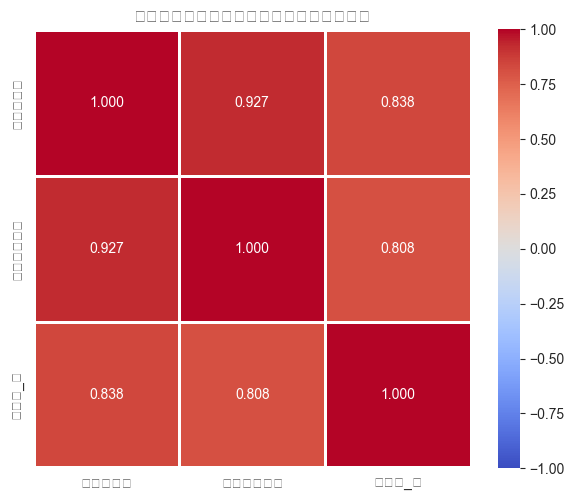


入社時年齢・前職経験月数の相関は0.93と非常に強く、初任給_円との相関も0.8台と強い。
VIFは7〜8台で、3変数を線形モデルにそのまま投入すると係数が不安定になるリスクがある。
→ 線形モデル(ロジスティック回帰)では正則化(L2)を必須とする、またはPCA/主成分1本にまとめる対応を検討。


In [30]:
# 数値変数間の相関とVIFの計算
numeric_persona_cols3 = ['入社時年齢', '前職経験月数', '初任給_円']
corr3 = train_persona[numeric_persona_cols3].corr()

print("="*60)
print("数値変数間の相関行列")
print("="*60)
print(corr3.round(3))

def calc_vif(df, cols):
    result = {}
    X = df[cols].dropna()
    for c in cols:
        y = X[c].values
        others = [cc for cc in cols if cc != c]
        A = np.column_stack([X[others].values, np.ones(len(X))])
        coef, *_ = np.linalg.lstsq(A, y, rcond=None)
        pred = A @ coef
        ss_res = np.sum((y - pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        result[c] = 1 / (1 - r2) if r2 < 1 else np.inf
    return result

vif_result = calc_vif(train_persona, numeric_persona_cols3)
print("\n" + "="*60)
print("VIF（分散拡大係数）")
print("="*60)
for col, v in vif_result.items():
    flag = "**多重共線性が強い**" if v > 5 else ""
    print(f"{col:12s}: VIF = {v:6.2f}  {flag}")

# 可視化
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr3, annot=True, fmt='.3f', cmap='coolwarm', center=0, square=True,
            linewidths=1, ax=ax, vmin=-1, vmax=1)
ax.set_title('数値変数間の相関（多重共線性チェック）')
plt.tight_layout()
plt.show()

print("\n入社時年齢・前職経験月数の相関は0.93と非常に強く、初任給_円との相関も0.8台と強い。")
print("VIFは7〜8台で、3変数を線形モデルにそのまま投入すると係数が不安定になるリスクがある。")
print("→ 線形モデル(ロジスティック回帰)では正則化(L2)を必須とする、またはPCA/主成分1本にまとめる対応を検討。")

## 13. 高カーディナリティ変数（部署ID・上司ID）の定着率分析

初期部署ID（461種）・上司ID（月次データで1,556種）は高カーディナリティで、Target Encodingの候補として既存レポートでも言及されていたが、
実際にどの程度カーディナリティが高く、集計単位として意味があるか（＝十分なサンプル数のグループが存在するか）は未検証だった。

In [31]:
# 部署ID・上司ID（入社月時点）ごとの定着率分析
month0_data_v2 = train_monthly_labeled[train_monthly_labeled['経過月数'] == 0].copy()

print("="*80)
print("高カーディナリティ変数の定着率分析（入社月時点）")
print("="*80)

for col in ['部署ID', '上司ID']:
    n_unique = month0_data_v2[col].nunique()
    grp = month0_data_v2.groupby(col)[target_col].agg(['mean', 'count'])
    print(f"\n【{col}】 ユニーク数={n_unique}（社員数={len(month0_data_v2)}に対し、1グループ平均{len(month0_data_v2)/n_unique:.1f}名）")
    for th in [3, 5, 10]:
        n_groups = len(grp[grp['count'] >= th])
        print(f"  サンプル数 >= {th} のグループ数: {n_groups}")
    grp10 = grp[grp['count'] >= 10]
    if len(grp10) > 0:
        print(f"  n>=10のグループにおける定着率レンジ: {grp10['mean'].min():.3f} 〜 {grp10['mean'].max():.3f}"
              f"（全体平均={target_ratio:.3f}）")
    else:
        print("  n>=10のグループなし（Target Encodingにはスムージング必須）")

高カーディナリティ変数の定着率分析（入社月時点）

【部署ID】 ユニーク数=461（社員数=2761に対し、1グループ平均6.0名）
  サンプル数 >= 3 のグループ数: 415
  サンプル数 >= 5 のグループ数: 315
  サンプル数 >= 10 のグループ数: 52
  n>=10のグループにおける定着率レンジ: 0.000 〜 0.818（全体平均=0.565）

【上司ID】 ユニーク数=1412（社員数=2761に対し、1グループ平均2.0名）
  サンプル数 >= 3 のグループ数: 368
  サンプル数 >= 5 のグループ数: 42
  サンプル数 >= 10 のグループ数: 0
  n>=10のグループなし（Target Encodingにはスムージング必須）


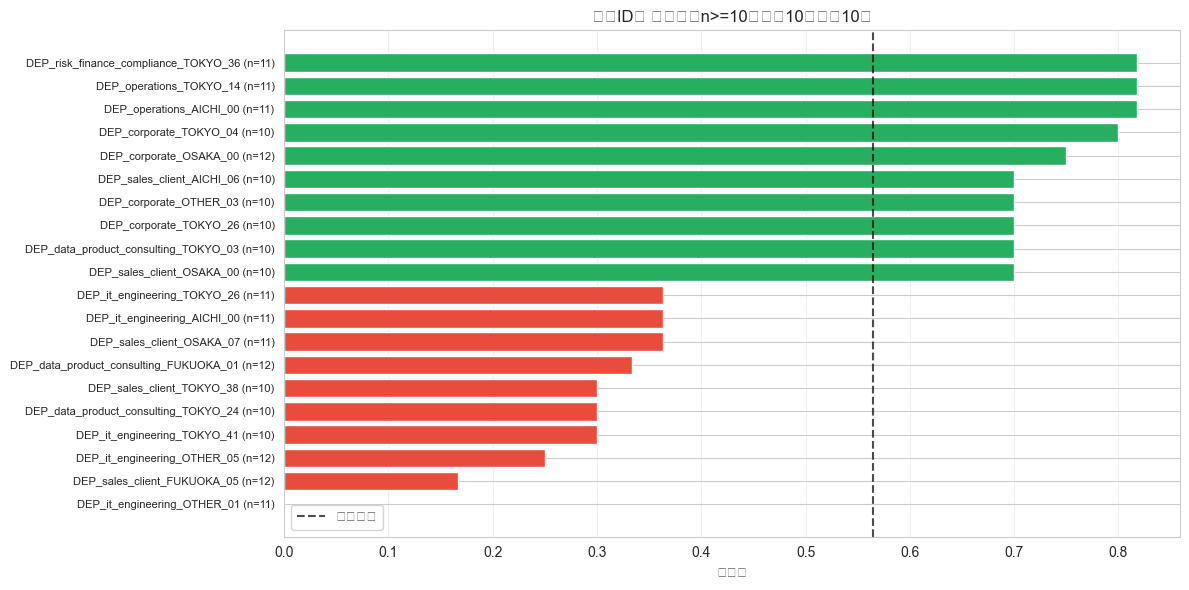

部署間の定着率の分散が大きい（0%〜82%）ことから、部署IDは強力な特徴量候補。
上司IDはn>=10のグループが存在せず、そのままの単位でのTarget Encodingは過学習リスクが高い。
→ 部署IDはCVベースのTarget Encoding+スムージング、上司IDは部署等の上位単位への集約または見送りが妥当。


In [32]:
# 部署ID（n>=10）の定着率トップ/ワースト
dept_grp = month0_data_v2.groupby('部署ID')[target_col].agg(['mean', 'count'])
dept_grp10 = dept_grp[dept_grp['count'] >= 10].sort_values('mean')

fig, ax = plt.subplots(figsize=(12, 6))
top_bottom = pd.concat([dept_grp10.head(10), dept_grp10.tail(10)])
colors = ['#e74c3c' if v < target_ratio else '#27ae60' for v in top_bottom['mean']]
ax.barh(range(len(top_bottom)), top_bottom['mean'], color=colors)
ax.set_yticks(range(len(top_bottom)))
ax.set_yticklabels([f"{idx} (n={int(c)})" for idx, c in zip(top_bottom.index, top_bottom['count'])], fontsize=8)
ax.axvline(x=target_ratio, color='black', linestyle='--', alpha=0.7, label='全体平均')
ax.set_xlabel('定着率')
ax.set_title('部署ID別 定着率（n>=10、下位10・上位10）')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"部署間の定着率の分散が大きい（0%〜82%）ことから、部署IDは強力な特徴量候補。")
print(f"上司IDはn>=10のグループが存在せず、そのままの単位でのTarget Encodingは過学習リスクが高い。")
print(f"→ 部署IDはCVベースのTarget Encoding+スムージング、上司IDは部署等の上位単位への集約または見送りが妥当。")

## 14. 初期職種別の定着率・研修時間の関係精査

既存レポート（深掘りEDA第2弾 17.1節）では「研修時間の負の相関は、離職率が高い職種ほど研修時間が長いという構造的要因」という考察が
文章で示されていたが、対応するコードがノートブックに存在しなかった。ここで数値を再現し、コードとして残す。

In [33]:
# 初期職種別の定着率（数値の明示）
print("="*80)
print("初期職種別の定着率")
print("="*80)
job_retention = train_persona.groupby('初期職種')[target_col].agg(['mean', 'count']).sort_values('mean', ascending=False)
job_retention.columns = ['定着率', '社員数']
print(job_retention)
print(f"\n職種間の定着率差: {job_retention['定着率'].max() - job_retention['定着率'].min():.1%}pt "
      f"(最高: {job_retention['定着率'].idxmax()} / 最低: {job_retention['定着率'].idxmin()})")

初期職種別の定着率
                        定着率  社員数
初期職種                            
リスク・金融・コンプライアンス    0.690217  368
コーポレート             0.682620  397
業務運用               0.678439  538
データ・商品企画・コンサルティング  0.492537  268
営業・顧客対応            0.490787  597
IT・エンジニアリング        0.411467  593

職種間の定着率差: 27.9%pt (最高: リスク・金融・コンプライアンス / 最低: IT・エンジニアリング)


入社区分別: 研修時間と定着率の相関


中途    : 相関=-0.0421  平均研修時間=  31.8h  定着率=0.686  n=736
新卒    : 相関=-0.0241  平均研修時間= 110.6h  定着率=0.520  n=2025

初期職種別: 研修時間と定着率の相関
             初期職種        相関    平均研修時間      定着率   n
      IT・エンジニアリング -0.237043 89.943508 0.411467 593
          営業・顧客対応 -0.165816 88.185930 0.490787 597
データ・商品企画・コンサルティング -0.134910 93.621269 0.492537 268
  リスク・金融・コンプライアンス -0.129994 87.044837 0.690217 368
           コーポレート -0.116893 89.617128 0.682620 397
             業務運用 -0.060316 90.430297 0.678439 538


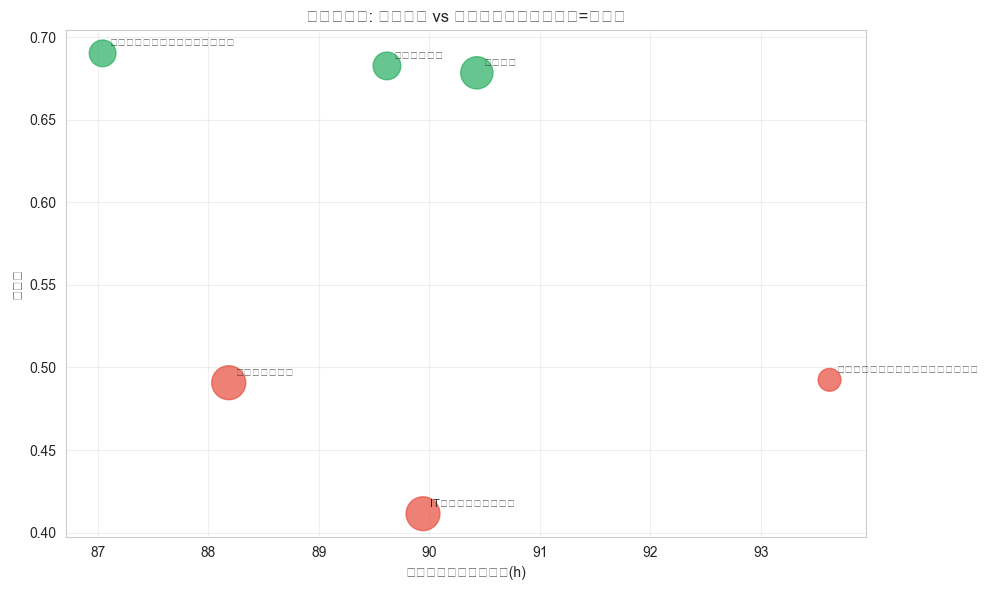


研修時間の絶対量は職種間でほぼ同水準（85-95h前後）だが、定着率は職種で大きく異なる。
研修時間と定着率の負の相関は、研修そのものの効果ではなく職種の構造的な定着率差を反映している。


In [34]:
# 入社区分別・初期職種別の研修時間（入社月）と定着率の関係
month0_job = month0_data_v2.merge(train_persona[['社員ID', '入社区分', '初期職種']], on='社員ID', how='left')

print("="*80)
print("入社区分別: 研修時間と定着率の相関")
print("="*80)
for cat, g in month0_job.groupby('入社区分'):
    corr_val = g['研修時間'].corr(g[target_col])
    print(f"{cat:6s}: 相関={corr_val:7.4f}  平均研修時間={g['研修時間'].mean():6.1f}h  定着率={g[target_col].mean():.3f}  n={len(g)}")

print()
print("="*80)
print("初期職種別: 研修時間と定着率の相関")
print("="*80)
job_train_corr = []
for job, g in month0_job.groupby('初期職種'):
    corr_val = g['研修時間'].corr(g[target_col])
    job_train_corr.append({'初期職種': job, '相関': corr_val, '平均研修時間': g['研修時間'].mean(),
                            '定着率': g[target_col].mean(), 'n': len(g)})
job_train_corr_df = pd.DataFrame(job_train_corr).sort_values('相関')
print(job_train_corr_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#27ae60' if v > 0.6 else '#e74c3c' for v in job_train_corr_df['定着率']]
ax.scatter(job_train_corr_df['平均研修時間'], job_train_corr_df['定着率'], s=job_train_corr_df['n'], c=colors, alpha=0.7)
for _, row in job_train_corr_df.iterrows():
    ax.annotate(row['初期職種'], (row['平均研修時間'], row['定着率']), fontsize=8, xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('入社月の平均研修時間(h)')
ax.set_ylabel('定着率')
ax.set_title('初期職種別: 研修時間 vs 定着率（バブルサイズ=人数）')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n研修時間の絶対量は職種間でほぼ同水準（85-95h前後）だが、定着率は職種で大きく異なる。")
print("研修時間と定着率の負の相関は、研修そのものの効果ではなく職種の構造的な定着率差を反映している。")

## 15. 入社年・入社四半期別の定着率

既存レポート17.4節の「Q2（4-6月）入社の定着率が最も低い」という発見も文章のみでコードが無かった。
入社四半期×入社区分のクロス集計まで含めて再現する。

In [35]:
# 入社年・入社四半期別の定着率
tp_v2 = train_persona.copy()
tp_v2['入社日dt'] = pd.to_datetime(tp_v2['入社日'])
tp_v2['入社年'] = tp_v2['入社日dt'].dt.year
tp_v2['入社四半期'] = tp_v2['入社日dt'].dt.quarter

print("="*60)
print("入社年別の定着率")
print("="*60)
print(tp_v2.groupby('入社年')[target_col].agg(['mean', 'count']))

print()
print("="*60)
print("入社四半期別の定着率")
print("="*60)
print(tp_v2.groupby('入社四半期')[target_col].agg(['mean', 'count']))

print()
print("="*60)
print("入社四半期 × 入社区分 の定着率")
print("="*60)
print(tp_v2.groupby(['入社四半期', '入社区分'])[target_col].agg(['mean', 'count']))

入社年別の定着率
          mean  count
入社年                  
2011  0.568182    836
2012  0.544799    971
2013  0.577181    894
2014  0.650000     60

入社四半期別の定着率
           mean  count
入社四半期                 
1      0.691275    149
2      0.537845   2246
3      0.668750    160
4      0.684466    206

入社四半期 × 入社区分 の定着率
                mean  count
入社四半期 入社区分                 
1     中途    0.691275    149
2     中途    0.696833    221
      新卒    0.520494   2025
3     中途    0.668750    160
4     中途    0.684466    206


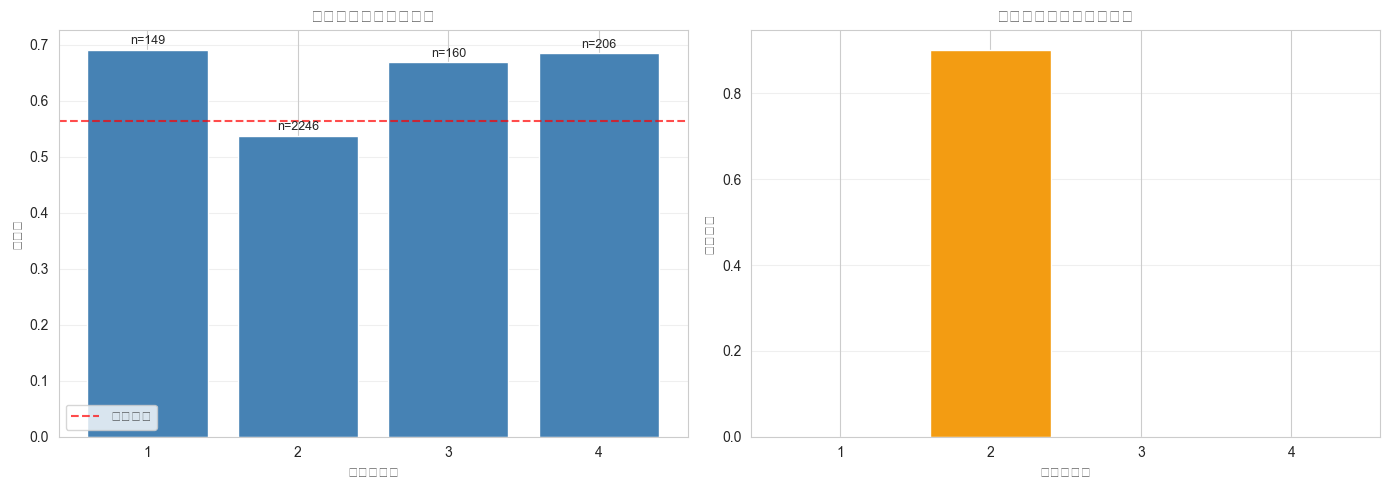

Q2（4-6月）は全体の81%を占める新卒一括採用の時期で、新卒比率が突出して高く、定着率が最も低い。
入社四半期の効果は、実質的には新卒/中途比率の違いによって説明される部分が大きい。


In [36]:
# 可視化：入社四半期別の定着率と入社区分の内訳
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

q_stats = tp_v2.groupby('入社四半期')[target_col].agg(['mean', 'count'])
bars = axes[0].bar(q_stats.index.astype(str), q_stats['mean'], color='steelblue')
axes[0].axhline(y=target_ratio, color='red', linestyle='--', alpha=0.7, label='全体平均')
for bar, c in zip(bars, q_stats['count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'n={int(c)}', ha='center', fontsize=9)
axes[0].set_xlabel('入社四半期')
axes[0].set_ylabel('定着率')
axes[0].set_title('入社四半期別の定着率')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

new_grad_ratio = tp_v2.groupby('入社四半期').apply(lambda g: (g['入社区分'] == '新卒').mean())
axes[1].bar(new_grad_ratio.index.astype(str), new_grad_ratio.values, color='#f39c12')
axes[1].set_xlabel('入社四半期')
axes[1].set_ylabel('新卒比率')
axes[1].set_title('入社四半期別の新卒比率')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Q2（4-6月）は全体の81%を占める新卒一括採用の時期で、新卒比率が突出して高く、定着率が最も低い。")
print("入社四半期の効果は、実質的には新卒/中途比率の違いによって説明される部分が大きい。")

## 16. 360度評価の初回実施タイミングと定着率

既存レポート17.5節の「標準タイミング（5-6ヶ月）が最も定着率が低い」という発見のコード化。

In [37]:
# 初回360度評価のタイミング分析
eval_flag_rows = train_monthly_labeled[train_monthly_labeled['360度評価更新フラグ'] == 1]
first_eval_month = eval_flag_rows.groupby('社員ID')['経過月数'].min().rename('初回評価月')

print("="*60)
print("初回360度評価タイミングの統計量")
print("="*60)
print(first_eval_month.describe())

fe = first_eval_month.reset_index().merge(train_persona[['社員ID', target_col]], on='社員ID', how='left')
bins = [-1, 2, 4, 6, 100]
labels = ['0-2ヶ月', '3-4ヶ月', '5-6ヶ月', '7ヶ月以降']
fe['タイミング区分'] = pd.cut(fe['初回評価月'], bins=bins, labels=labels)

print()
print("="*60)
print("初回評価タイミング区分別の定着率")
print("="*60)
timing_stats = fe.groupby('タイミング区分', observed=True)[target_col].agg(['mean', 'count'])
print(timing_stats)

初回360度評価タイミングの統計量
count    2761.000000
mean        4.923216
std         0.915194
min         2.000000
25%         5.000000
50%         5.000000
75%         5.000000
max        13.000000
Name: 初回評価月, dtype: float64

初回評価タイミング区分別の定着率
             mean  count
タイミング区分                 
0-2ヶ月    0.608696     92
3-4ヶ月    0.692308    208
5-6ヶ月    0.547074   2358
7ヶ月以降    0.669903    103


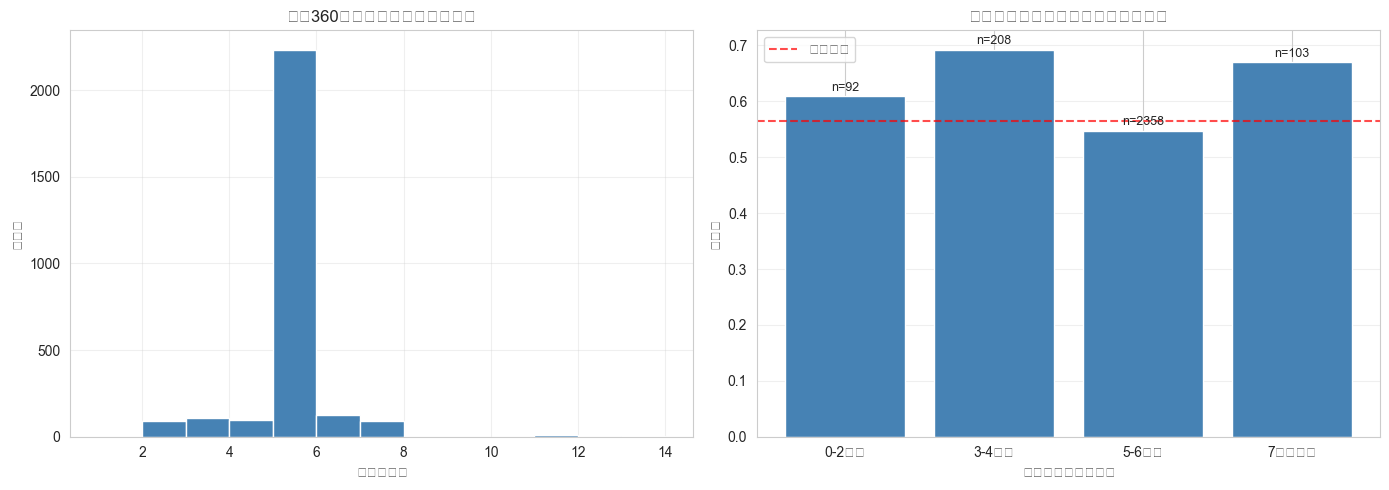

全体の85%が5-6ヶ月目に初回評価を受ける「標準」タイミングだが、この群の定着率が最も低い(54.7%)。
一方、3-4ヶ月の早期評価群は定着率69.2%と最も高い。ただしサンプルサイズや評価タイミングを決める要因
（配属先の運用差など）が交絡している可能性があり、因果関係の解釈には注意が必要。


In [38]:
# 可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(first_eval_month, bins=range(1, 15), color='steelblue', edgecolor='white')
axes[0].set_xlabel('初回評価月')
axes[0].set_ylabel('社員数')
axes[0].set_title('初回360度評価タイミングの分布')
axes[0].grid(alpha=0.3)

bars = axes[1].bar(timing_stats.index.astype(str), timing_stats['mean'], color='steelblue')
axes[1].axhline(y=target_ratio, color='red', linestyle='--', alpha=0.7, label='全体平均')
for bar, c in zip(bars, timing_stats['count']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'n={int(c)}', ha='center', fontsize=9)
axes[1].set_xlabel('初回評価タイミング')
axes[1].set_ylabel('定着率')
axes[1].set_title('初回評価タイミング区分別の定着率')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("全体の85%が5-6ヶ月目に初回評価を受ける「標準」タイミングだが、この群の定着率が最も低い(54.7%)。")
print("一方、3-4ヶ月の早期評価群は定着率69.2%と最も高い。ただしサンプルサイズや評価タイミングを決める要因")
print("（配属先の運用差など）が交絡している可能性があり、因果関係の解釈には注意が必要。")

## 17. full.csvを用いた生存分析的アプローチ（離職タイミングの深掘り）

既存レポート17.2節は離職者の期間別内訳を表としてまとめていたが、生存曲線（在籍率の推移）としての可視化や、
「0-23ヶ月の特徴量が実際にどの離職タイミングを予測しているのか」という検証は行われていなかった。
`employee_monthly_train_full.csv`（学習用社員のみ、0-119ヶ月）を用いて、以下を追加分析する。

1. 120ヶ月間の在籍率推移（生存曲線）
2. 早期（12-23ヶ月）・中期（24-59ヶ月）・後期（60-119ヶ月）離職者と定着者で、0-23ヶ月の特徴量水準がどう違うか

**注意**: この分析はfull.csvの構造理解のためのものであり、24ヶ月目以降の情報を特徴量として直接使うとデータリークになる。

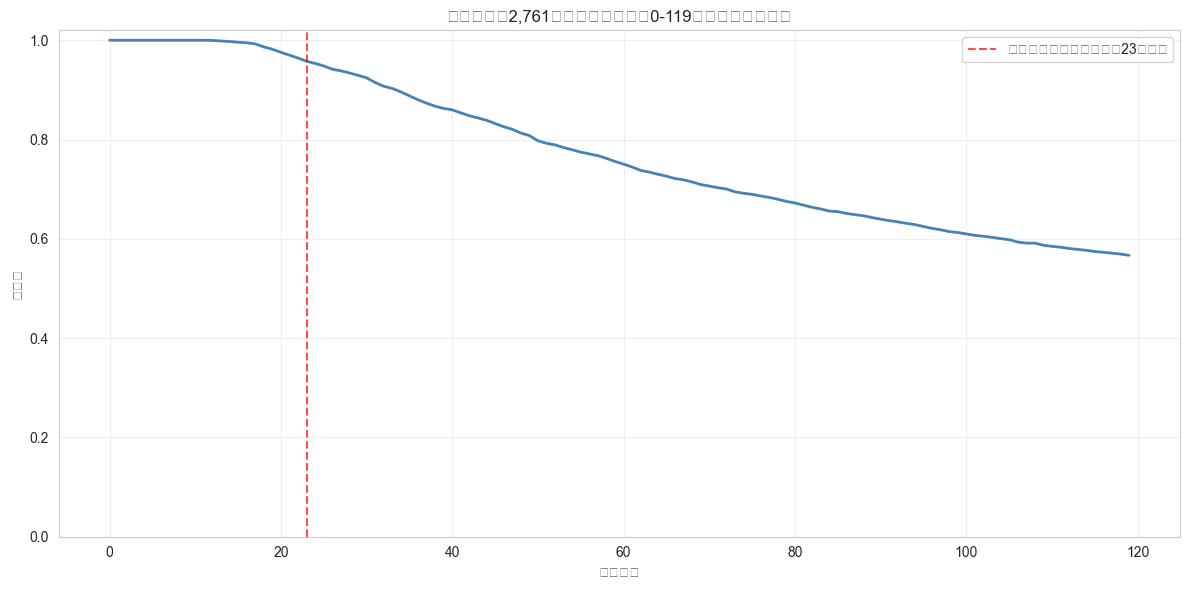

経過月数と在籍率:
    0ヶ月: 在籍率 1.0000
   12ヶ月: 在籍率 0.9996
   23ヶ月: 在籍率 0.9576
   24ヶ月: 在籍率 0.9533
   36ヶ月: 在籍率 0.8801
   48ヶ月: 在籍率 0.8131
   60ヶ月: 在籍率 0.7505
   72ヶ月: 在籍率 0.7005
   84ヶ月: 在籍率 0.6559
   96ヶ月: 在籍率 0.6212
  108ヶ月: 在籍率 0.5915
  119ヶ月: 在籍率 0.5668

Test/Trainが観測できる23ヶ月時点では在籍率95.8%だが、
最終的な10年後の在籍率は56.7%。差分の39.1%ptは
24ヶ月目以降にのみ現れる離職であり、0-23ヶ月のデータだけでは原理的に捉えきれない部分がある。


In [39]:
# 生存曲線（在籍率の推移）の計算
last_month_full = train_monthly_full.groupby('社員ID')['経過月数'].max().rename('最終経過月数')
survival_df = train_persona[['社員ID', target_col]].merge(last_month_full, on='社員ID', how='left')

max_m = 119
n_total = len(survival_df)
alive_fraction = []
for m in range(0, max_m + 1):
    alive = ((survival_df[target_col] == 1) | (survival_df['最終経過月数'] >= m)).sum()
    alive_fraction.append(alive / n_total)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(range(0, max_m + 1), alive_fraction, color='steelblue', linewidth=2)
ax.axvline(x=23, color='red', linestyle='--', alpha=0.7, label='観測可能な範囲の終端（23ヶ月）')
ax.set_xlabel('経過月数')
ax.set_ylabel('在籍率')
ax.set_title('学習用社員2,761名の在籍率推移（0-119ヶ月、生存曲線）')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

print("経過月数と在籍率:")
for m in [0, 12, 23, 24, 36, 48, 60, 72, 84, 96, 108, 119]:
    print(f"  {m:3d}ヶ月: 在籍率 {alive_fraction[m]:.4f}")

print(f"\nTest/Trainが観測できる23ヶ月時点では在籍率{alive_fraction[23]:.1%}だが、")
print(f"最終的な10年後の在籍率は{alive_fraction[119]:.1%}。差分の{alive_fraction[23]-alive_fraction[119]:.1%}ptは")
print("24ヶ月目以降にのみ現れる離職であり、0-23ヶ月のデータだけでは原理的に捉えきれない部分がある。")

離職時期区分ごとの人数:
離職時期区分
中期離職(24-59mo)     560
後期離職(60-119mo)    513
早期離職(12-23mo)     129
Name: count, dtype: int64

0-23ヶ月の特徴量水準：定着者 vs 早期/中期/後期離職者
定着(10年)             : n=1559  平均残業時間= 13.46h  平均360度評価_親和度=3.123
早期離職(12-23mo)       : n= 129  平均残業時間= 39.21h  平均360度評価_親和度=3.075
中期離職(24-59mo)       : n= 560  平均残業時間= 20.40h  平均360度評価_親和度=3.085
後期離職(60-119mo)      : n= 513  平均残業時間= 14.07h  平均360度評価_親和度=3.114


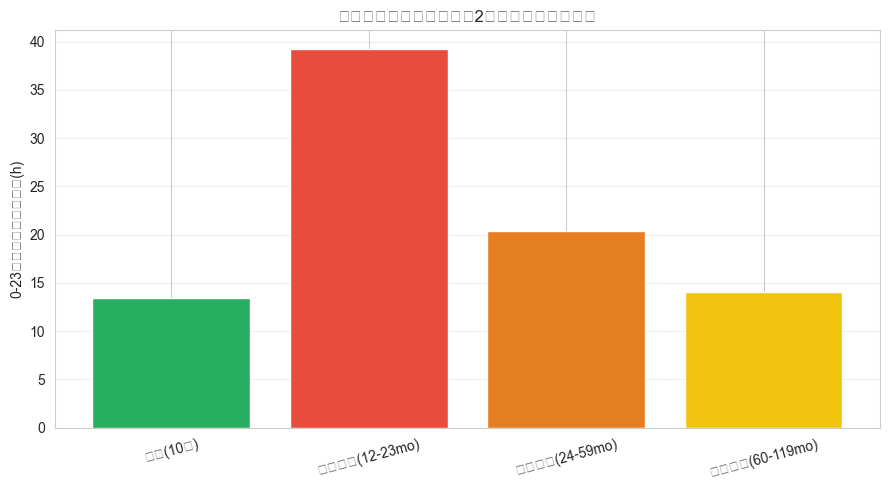


最も重要な発見: 0-23ヶ月の残業時間で明確な差があるのは「早期離職者」のみ（定着者の約3倍）。
中期離職者はやや高め、後期離職者は定着者とほぼ同水準であり、0-23ヶ月のシグナルだけでは判別が難しい。
→ 0-23ヶ月の特徴量が最も強く効くのは「早期離職の予測」であり、4年目以降に離職する層
  （全離職者の73%）を捉えるのは、入社直後データからは本質的に困難であることが定量的に確認できる。


In [40]:
# 早期・中期・後期離職者と定着者で、0-23ヶ月の特徴量水準を比較
leavers = survival_df[survival_df[target_col] == 0].copy()
leavers['離職時期区分'] = pd.cut(
    leavers['最終経過月数'], bins=[10, 23, 59, 119],
    labels=['早期離職(12-23mo)', '中期離職(24-59mo)', '後期離職(60-119mo)']
)
print("離職時期区分ごとの人数:")
print(leavers['離職時期区分'].value_counts())

stayers_ids = survival_df[survival_df[target_col] == 1]['社員ID']
early_ids = leavers[leavers['離職時期区分'] == '早期離職(12-23mo)']['社員ID']
mid_ids = leavers[leavers['離職時期区分'] == '中期離職(24-59mo)']['社員ID']
late_ids = leavers[leavers['離職時期区分'] == '後期離職(60-119mo)']['社員ID']

# 0-23ヶ月の平均残業時間・360度評価_親和度で比較（Trainの0-23ヶ月データを使用、リークなし）
ot_mean = train_monthly.groupby('社員ID')['残業時間'].mean()
eval_mean = train_monthly.groupby('社員ID')['360度評価_親和度'].mean()

print()
print("="*80)
print("0-23ヶ月の特徴量水準：定着者 vs 早期/中期/後期離職者")
print("="*80)
compare_rows = []
for name, ids in [('定着(10年)', stayers_ids), ('早期離職(12-23mo)', early_ids),
                   ('中期離職(24-59mo)', mid_ids), ('後期離職(60-119mo)', late_ids)]:
    ot = ot_mean.loc[ot_mean.index.isin(ids)]
    ev = eval_mean.loc[eval_mean.index.isin(ids)]
    compare_rows.append({'グループ': name, 'n': len(ids), '0-23mo平均残業時間': ot.mean(), '0-23mo平均360度評価_親和度': ev.mean()})
    print(f"{name:20s}: n={len(ids):4d}  平均残業時間={ot.mean():6.2f}h  平均360度評価_親和度={ev.mean():.3f}")

compare_df = pd.DataFrame(compare_rows)

fig, ax = plt.subplots(figsize=(9, 5))
colors_c = ['#27ae60', '#e74c3c', '#e67e22', '#f1c40f']
ax.bar(compare_df['グループ'], compare_df['0-23mo平均残業時間'], color=colors_c)
ax.set_ylabel('0-23ヶ月の平均残業時間(h)')
ax.set_title('離職タイミング別の入社2年間の平均残業時間')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n最も重要な発見: 0-23ヶ月の残業時間で明確な差があるのは「早期離職者」のみ（定着者の約3倍）。")
print("中期離職者はやや高め、後期離職者は定着者とほぼ同水準であり、0-23ヶ月のシグナルだけでは判別が難しい。")
print("→ 0-23ヶ月の特徴量が最も強く効くのは「早期離職の予測」であり、4年目以降に離職する層")
print("  （全離職者の73%）を捉えるのは、入社直後データからは本質的に困難であることが定量的に確認できる。")

## 18. 初任給と初期等級の整合性チェック

初任給と初期等級（G1〜G5）は強い相関を持つはずのペア。整合性を確認し、等級内での給与偏差が定着に関係するかを検証する。

In [41]:
# 初期等級別の初任給分布
grade_order = ['G1', 'G2', 'G3', 'G4', 'G5']
print("="*80)
print("初期等級別の初任給_円")
print("="*80)
print(train_persona.groupby('初期等級')[target_col].agg(['mean', 'count']))
print()
print(train_persona.groupby('初期等級')['初任給_円'].describe()[['count', 'mean', 'std', 'min', 'max']].loc[grade_order])

grade_map = {g: i + 1 for i, g in enumerate(grade_order)}
grade_corr = train_persona['初任給_円'].corr(train_persona['初期等級'].map(grade_map))
print(f"\n初任給と初期等級(順序)の相関: {grade_corr:.4f}（整合性は高い）")

初期等級別の初任給_円
          mean  count
初期等級                 
G1    0.525965   2099
G2    0.618677    257
G3    0.685512    283
G4    0.814815    108
G5    1.000000     14

       count           mean           std       min       max
初期等級                                                         
G1    2099.0  223554.549786  22532.896236  159000.0  282000.0
G2     257.0  273704.280156  26053.694952  202000.0  345000.0
G3     283.0  336063.604240  26193.554992  264000.0  400000.0
G4     108.0  403842.592593  34511.588745  323000.0  480000.0
G5      14.0  503571.428571  30351.059507  438000.0  542000.0

初任給と初期等級(順序)の相関: 0.9021（整合性は高い）


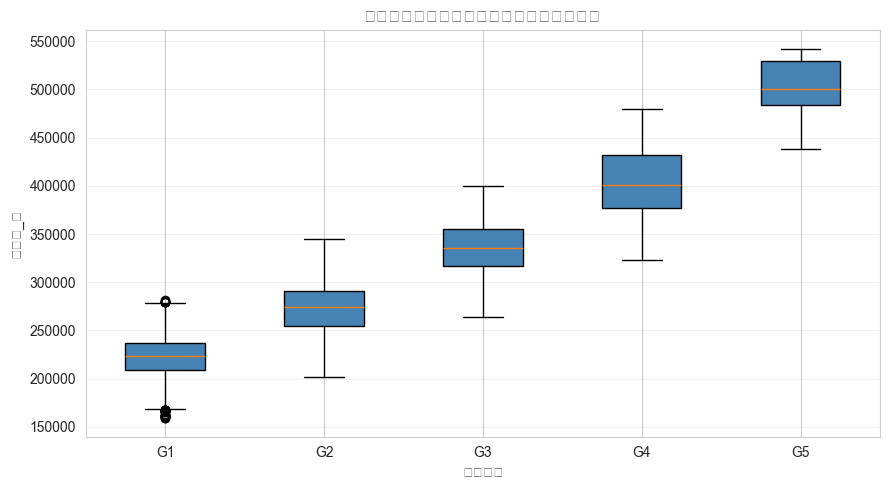

等級内給与偏差と定着ラベルの相関: -0.0305
10年定着ラベル
0    827.529849
1   -638.031353
Name: 給与偏差_等級内, dtype: float64

初任給は初期等級とほぼ整合的（相関0.90）で、明確な矛盾ケースは見られない。
等級内での給与偏差（同じ等級の中で高給/低給か）は定着との相関が弱く(-0.03程度)、単独の特徴量としての効果は限定的。


In [42]:
# 等級内の給与偏差と定着率の関係
fig, ax = plt.subplots(figsize=(9, 5))
data_by_grade = [train_persona[train_persona['初期等級'] == g]['初任給_円'].values for g in grade_order]
bp = ax.boxplot(data_by_grade, labels=grade_order, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
ax.set_xlabel('初期等級')
ax.set_ylabel('初任給_円')
ax.set_title('初期等級別の初任給分布（整合性の確認）')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

grade_mean_salary = train_persona.groupby('初期等級')['初任給_円'].transform('mean')
train_persona['給与偏差_等級内'] = train_persona['初任給_円'] - grade_mean_salary
resid_corr = train_persona['給与偏差_等級内'].corr(train_persona[target_col])
print(f"等級内給与偏差と定着ラベルの相関: {resid_corr:.4f}")
print(train_persona.groupby(target_col)['給与偏差_等級内'].mean())
print("\n初任給は初期等級とほぼ整合的（相関0.90）で、明確な矛盾ケースは見られない。")
print("等級内での給与偏差（同じ等級の中で高給/低給か）は定着との相関が弱く(-0.03程度)、単独の特徴量としての効果は限定的。")

## 19. v2追加分析のまとめ

### 19.1 既存レポートとノートブックコードのギャップ解消

初回レポート（`data_exploration_report.md`）の「深掘りEDA第2弾」（17.1〜17.5節）は、分析結果の記述はあったが対応するコードがノートブックに存在しなかった。
本v2では、研修時間の職種別精査（14節）、入社年・四半期別定着率（15節）、360度評価タイミング（16節）を実行可能なコードとして再現し、数値を再検証した。

### 19.2 新たに追加した分析と主な発見

| 節 | 分析内容 | 主な発見 |
|---|---|---|
| 10 | Train/Test分布比較（KS検定） | 初任給・月例給与に明確な分布シフト（KS statが大、p≈0）。属性・行動系の変数はTrain/Testでほぼ同分布 |
| 11 | 統計的検定（カイ二乗・Mann-Whitney） | 最終学歴以外の主要カテゴリカル変数・数値変数はすべて統計的に有意（p<0.05）。ただし効果量(Cramer's V)は小〜中程度 |
| 12 | 多重共線性チェック（VIF） | 入社時年齢・前職経験月数・初任給_円のVIFは7〜8台で多重共線性が強い。線形モデルでは正則化必須 |
| 13 | 高カーディナリティ変数の定着率分析 | 部署ID（n>=10）の定着率は0%〜82%と分散が大きく強力な特徴量候補。上司IDはn>=10のグループが存在せずそのままの単位でのTarget Encodingは困難 |
| 14 | 職種別 研修時間×定着率 | 研修時間の絶対量は職種間でほぼ同水準。負の相関は職種による構造的な定着率差を反映するものであり、研修自体の効果ではない |
| 15 | 入社年・四半期別定着率 | Q2（新卒一括採用期、全体の81%）は新卒比率が高いために定着率が低く見える。四半期の効果は新卒/中途比率で大部分説明可能 |
| 16 | 360度評価の初回タイミング | 標準タイミング（5-6ヶ月、全体の85%）の定着率が最も低い(54.7%)。ただし交絡の可能性があり因果解釈には注意 |
| 17 | full.csvによる生存分析 | 23ヶ月時点の在籍率は95.3%だが120ヶ月時点は56.7%。0-23ヶ月の残業時間が顕著に高いのは「早期離職者」のみで、後期離職者(60-119mo)は定着者とほぼ同水準 → 0-23ヶ月データは早期離職の予測には強いが、離職の73%を占める4年目以降の離職を予測するのは本質的に難しい |
| 18 | 初任給×初期等級の整合性 | 相関0.90と高く整合的。矛盾ケースは目立たず、等級内給与偏差の定着への効果は弱い(-0.03) |

### 19.3 特徴量エンジニアリングへの追加示唆

1. **給与系特徴量は相対値で扱う**: 初任給・月例給与はTrain/Testで分布がシフトしているため、絶対額よりも「入社時等級内での偏差」「同期入社者内での相対順位」など相対化した特徴量の方が頑健
2. **多重共線性対策**: 年齢・前職経験・初任給は同時投入せず、正則化またはPCA等での次元集約を検討
3. **部署IDはCVベースのTarget Encoding（スムージング付き）で活用、上司IDは単独では見送るか部署等の上位単位に集約**
4. **「早期離職」と「後期離職」を分けて考える**: 0-23ヶ月の特徴量は主に早期離職（12-23ヶ月）の予測に効いており、離職者の73%を占める4年目以降の離職を捉えるには限界がある。Log Lossの改善余地はあるが、過度な期待は禁物というのが定量的にも裏付けられた
5. **入社四半期は新卒/中途フラグとの交互作用、または新卒フラグそのものが本質的な説明変数**

### 19.4 次のアクション

* 部署IDのTarget Encoding（CV内、スムージング付き）をベースラインモデルに追加
* 初任給・月例給与を「等級内偏差」「入社四半期内偏差」に置き換えた特徴量を追加
* 早期離職(12-23ヶ月)と中長期離職を区別した補助タスク・分析の検討
* full.csvの残業時間トレンドなど、0-23ヶ月で観測可能な「悪化トレンド」系特徴量を優先的に実装

---

**レポート作成者**: Data Science Team
**最終更新日**: 2026年8月8日
**版**: v2 - 既存レポートとの整合＋追加分析
